# iHMP Multioutput GP Analysis

Apply the multioutput Gaussian process (MOGP) model to iHMP metabolomics data from Crohn's disease participants. The MOGP jointly models all metabolites to discover latent factors (modules) that capture shared temporal structure.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from waveome.kernels import Categorical
from waveome.model_search import GPSearch

plt.rcParams["font.size"] = 9
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["axes.titlesize"] = 9
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

/Users/allen/miniforge3/envs/mogp-waveome-sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-03 13:52:54,487	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Data Preparation

In [2]:
# Load metabolomics data
mbx_raw = pd.read_csv('../examples/iHMP/data/iHMP_metabolomics.csv', low_memory=False)

# Save lookup table for labeled metabolites
mbx_lookup = mbx_raw.loc[
    mbx_raw['Metabolite'].notna(),
    ['HMDB (*Representative ID)', 'Metabolite', 'Compound']
].copy()

# Transpose to samples (rows) × metabolites (columns)
mbx = (
    mbx_raw
    .drop(columns=mbx_raw.columns[:6])
    .set_index('Compound')
    .transpose()
    .reset_index(names='External ID')
    .fillna(0.)
    .set_index('External ID')
    .sort_index()
)

# Keep only labeled metabolites with non-zero median
labeled_compounds = set(mbx_lookup['Compound'])
labeled_mask = mbx.columns.isin(labeled_compounds)
median_mask = mbx.quantile(q=0.5, axis=0) > 0
mbx = mbx.loc[:, labeled_mask & median_mask]

print(f"Metabolomics: {mbx.shape[0]} samples × {mbx.shape[1]} metabolites")
mbx.head()

Metabolomics: 546 samples × 564 metabolites


Compound,C18n_QI06,C18n_QI07,C18n_QI08,C18n_QI10,C18n_QI11,C18n_TF1,C18n_QI12,C18n_QI13,C18n_QI14,C18n_TF2,...,HILp_QI13155,HILp_TF17,HILp_TF35,HILp_TF19,HILp_QI25304,HILp_TF2,HILp_TF3,HILp_TF12,HILp_QI23736,HILp_QI24373
External ID,,,,,,,,,,,,,,,,,,,,,
CSM5FZ3N,942546.0,1418451.0,2194.0,38180.0,5893.0,0.0,4174.0,211440.0,15667.0,376297.0,...,19777461.0,9997928.0,3579319.0,2066660.0,86595.0,274385476.0,136360623.0,2.119068e+08,36328.0,586321.0
CSM5FZ3T,470132.0,416924.0,28.0,11781.0,6345.0,0.0,5257.0,29713.0,2833.0,0.0,...,34863534.0,69914375.0,6996249.0,15657037.0,1162223.0,70872089.0,5868952.0,3.456104e+09,119223.0,3284388.0
CSM5FZ44,720369.0,1198835.0,436.0,8721.0,14372.0,0.0,5462.0,86293.0,64553.0,1010264.0,...,15526303.0,12300553.0,1812524.0,7134468.0,95476.0,90077297.0,10050253.0,9.373580e+08,0.0,323194.0
CSM5FZ48,1069292.0,1256069.0,773.0,62098.0,5653.0,0.0,3628.0,9523.0,18466.0,297950.0,...,14346185.0,14010937.0,4867731.0,17058734.0,0.0,250558333.0,238294493.0,3.669375e+08,36710.0,885943.0
CSM5FZ4A,1265301.0,1368667.0,542.0,3235743.0,10058.0,0.0,5165.0,25482.0,9282.0,484960.0,...,32308733.0,11756268.0,4435431.0,5256579.0,80735.0,6695543.0,872027.0,5.998712e+08,13503.0,1555485.0


In [3]:
# Deduplicate metabolites: same Metabolite name measured by multiple LC methods,
# or same TAG/DAG measured as NH4 adduct and native form.
# Strategy: for each duplicate group, keep the row with the lowest pooled QC CV
# (most analytically precise measurement). NH4-adduct pairs are handled the same way.
#
# Note: mbx (built in the previous cell) uses 'Compound' codes as column names,
# then maps to 'Metabolite' names via mbx_lookup. We filter mbx columns here
# to only keep the best Compound per metabolite base name.

def _base_metabolite_name(name):
    """Strip NH4_ prefix so adduct pairs share the same base name."""
    if isinstance(name, str) and name.startswith('NH4_'):
        return name[4:]
    return name

# Build a lookup: Compound -> (base_metabolite_name, CV)
mbx_cv = mbx_raw[['Compound', 'Metabolite', 'Pooled QC sample CV']].copy()
mbx_cv = mbx_cv.dropna(subset=['Metabolite', 'Pooled QC sample CV'])
mbx_cv['_base_name'] = mbx_cv['Metabolite'].apply(_base_metabolite_name)

# For each base metabolite name, keep the Compound with lowest CV
best_compounds = (
    mbx_cv
    .sort_values('Pooled QC sample CV')
    .drop_duplicates(subset='_base_name', keep='first')
    .set_index('_base_name')
)

# Stats before filtering
n_before = mbx_cv['Metabolite'].nunique()
n_adduct  = mbx_cv['Metabolite'].str.startswith('NH4_').sum()
n_exact   = mbx_cv[mbx_cv['Metabolite'].duplicated(keep=False)]['Metabolite'].nunique()

# Filter mbx columns to best compound per metabolite
keep_compounds = set(best_compounds['Compound'])
mbx = mbx.loc[:, mbx.columns.isin(keep_compounds)]

# Update mbx_lookup so metabolite name labels are correct (strip NH4_ from kept rows)
mbx_lookup = best_compounds[['Compound', 'Pooled QC sample CV']].reset_index().rename(
    columns={'_base_name': 'Metabolite'}
)

n_after = len(keep_compounds)
print(f"Before deduplication : {n_before} labeled metabolites")
print(f"  NH4-adduct rows    : {n_adduct}")
print(f"  Exact-name dups    : {n_exact} metabolite names with duplicates")
print(f"After deduplication  : {n_after} metabolites kept")
print(f"Removed              : {n_before - n_after} redundant measurements")
print(f"\nStrategy: lowest pooled QC CV wins within each duplicate/adduct group.")
print(f"\nmbx shape after dedup: {mbx.shape}")

Before deduplication : 551 labeled metabolites
  NH4-adduct rows    : 70
  Exact-name dups    : 44 metabolite names with duplicates
After deduplication  : 484 metabolites kept
Removed              : 67 redundant measurements

Strategy: lowest pooled QC CV wins within each duplicate/adduct group.

mbx shape after dedup: (546, 459)


In [4]:
# Load and prepare metadata (CD participants only)
mtd = pd.read_csv('../examples/iHMP/data/iHMP_metadata.csv', low_memory=False)

column_list = [
    'External ID', 'Participant ID', 'site_name', 'Age at diagnosis',
    'consent_age', 'diagnosis', 'General wellbeing',
    'hbi', 'date_of_receipt', 'race',
    'General well being over the past 24 hours', 'sex',
]

wellbeing_map = {
    "Very Well": "very well",
    "Slightly below par": "below par",
    "Poor": "poor",
    "Very Poor": "very poor",
    "Terrible": "very poor"
}

mtd_sub = (
    mtd
    .loc[mtd['data_type'].values == 'metabolomics', column_list]
    .query("diagnosis == 'CD'")
    .rename(columns={
        'Participant ID': 'participant_id',
        'Age at diagnosis': 'age_at_diagnosis',
    })
    .assign(study_days=lambda x: (
        pd.to_datetime(x['date_of_receipt'])
        - pd.to_datetime(x['date_of_receipt']).min()
    ).dt.days.astype("float"))
    .assign(min_id_study_days=lambda x: x.groupby("participant_id")["study_days"].transform('min'))
    .assign(age=lambda x: x['consent_age'] + ((x['study_days'] - x['min_id_study_days']) / 365.))
    .assign(general_wellbeing=lambda x: x['General wellbeing'].combine_first(
        x['General well being over the past 24 hours'])
    )
    .drop(columns=[
        'General wellbeing',
        'General well being over the past 24 hours',
        'date_of_receipt',
        'min_id_study_days',
        'diagnosis',
        'consent_age',
        'age_at_diagnosis',
    ])
    .dropna()
    .set_index('External ID')
    .sort_index()
)

mtd_sub["general_wellbeing"] = mtd_sub.general_wellbeing.map(wellbeing_map)

# Add time relative to max HBI event per individual
max_id_info = mtd_sub.groupby("participant_id").hbi.idxmax()
mtd_sub["time_from_max"] = (
    mtd_sub.study_days.values
    - mtd_sub.loc[max_id_info[mtd_sub["participant_id"]], "study_days"].values
)

print(f"Metadata: {mtd_sub.shape[0]} samples, {mtd_sub['participant_id'].nunique()} participants")
mtd_sub.head()

Metadata: 238 samples, 49 participants


,participant_id,site_name,hbi,race,sex,study_days,age,general_wellbeing,time_from_max
External ID,,,,,,,,,
CSM5FZ3N,C3001,Cedars-Sinai,4.0,White,Female,93.0,43.000000,below par,-271.0
CSM5FZ3T,C3002,Cedars-Sinai,9.0,White,Female,139.0,76.000000,poor,0.0
CSM5FZ44,C3002,Cedars-Sinai,7.0,White,Female,195.0,76.153425,below par,56.0
CSM5FZ4C,C3001,Cedars-Sinai,3.0,White,Female,149.0,43.153425,very well,-215.0
CSM5MCU4,C3008,Cedars-Sinai,0.0,White,Female,202.0,53.000000,very well,-49.0


In [5]:
# Align metabolomics and metadata
mbx_sub = mbx.loc[mbx.index.intersection(mtd_sub.index)]
mtd_sub = mtd_sub.loc[mbx_sub.index]
assert mtd_sub.index.equals(mbx_sub.index)

# Rename mbx_sub columns from Compound codes to Metabolite names.
# mbx_lookup maps Compound -> Metabolite (updated by the dedup cell to use base names).
compound_to_metabolite = mbx_lookup.set_index("Compound")["Metabolite"].to_dict()
mbx_sub = mbx_sub.rename(columns=compound_to_metabolite)

print(f"Aligned: {len(mbx_sub)} samples × {mbx_sub.shape[1]} metabolites")
print(f"Participants: {mtd_sub['participant_id'].nunique()}")
print(f"Median observations per participant: {mtd_sub.groupby('participant_id').size().median():.0f}")
print(f"Example metabolite names: {mbx_sub.columns[:5].tolist()}")

Aligned: 238 samples × 459 metabolites
Participants: 49
Median observations per participant: 5
Example metabolite names: ['12.13-diHOME', '9.10-diHOME', 'caproate', 'hydrocinnamate', 'mandelate']


## Multioutput GP Model

Fit the MOGP using Linear Coregionalization. The model discovers latent factors that capture shared temporal structure across all metabolites simultaneously. Covariates: `participant_id` (unit), `study_days`, `time_from_max`, `hbi`, `site_name`, `race`, `sex`, `general_wellbeing`, `age`.

In [6]:
import pickle
import gpflow

fp = "./output/ihmp_multioutput_fit.pkl"
os.makedirs("./output", exist_ok=True)

if os.path.exists(fp):
    print("Loading saved model...")
    with open(fp, "rb") as f:
        gps = pickle.load(f)
else:
    gps = GPSearch(
        X=mtd_sub,
        Y=mbx_sub,
        unit_col="participant_id",
        categorical_vars=["site_name", "race", "sex", "general_wellbeing"],
        outcome_likelihood="negativebinomial",
    )

    # Feature names in X order
    feat = list(gps.feat_names)

    # Specify latent kernels
    latent_kernels = [
        Categorical(active_dims=[feat.index("participant_id")]),
        Categorical(active_dims=[feat.index("site_name")]),
        Categorical(active_dims=[feat.index("race")]),
        Categorical(active_dims=[feat.index("sex")]),
        Categorical(active_dims=[feat.index("general_wellbeing")]),
        gpflow.kernels.SquaredExponential(active_dims=[feat.index("hbi")]),
        gpflow.kernels.SquaredExponential(active_dims=[feat.index("study_days")]),
        gpflow.kernels.Matern52(active_dims=[feat.index("time_from_max")]),
        gpflow.kernels.Periodic(gpflow.kernels.SquaredExponential(active_dims=[feat.index("study_days")])),
        gpflow.kernels.SquaredExponential(active_dims=[feat.index("age")]),
    ]


    gps.multioutput_penalized_optimization(
        penalization_factor=1.0,
        num_opt_iter=50000,
        verbose=True,
        random_seed=9102,
        latent_kernels=latent_kernels,
        adam_learning_rate=0.001,
    )


    # Save fitted model
    with open(fp, "wb") as f:
        pickle.dump(gps, f)

print(f"Model fitted with {gps.models['multioutput'].kernel.W.numpy().shape[1]} active latent factors")

Loading saved model...
Model fitted with 10 active latent factors


## W Matrix Stability Check

Run the model with multiple random seeds and check whether the loading patterns in W are consistent. W is only identified up to column permutation and sign flip, so we align columns across runs before comparing.

=== Seed 42 ===
Converting site_name to numeric
Converting race to numeric
Converting sex to numeric
Converting general_wellbeing to numeric
Converting participant_id to numeric
Instructions for updating:
Use fn_output_signature instead


Instructions for updating:
Use fn_output_signature instead


Seed 42: W shape = (459, 10)
=== Seed 1234 ===
Converting site_name to numeric
Converting race to numeric
Converting sex to numeric
Converting general_wellbeing to numeric
Converting participant_id to numeric


Seed 1234: W shape = (459, 10)
=== Seed 9999 ===
Converting site_name to numeric
Converting race to numeric
Converting sex to numeric
Converting general_wellbeing to numeric
Converting participant_id to numeric
Seed 9999: W shape = (459, 10)
Saved to ../multioutput/output/stability_W_runs.pkl
=== Per-factor stability (correlation with main fit) ===
Factor                     seed=42  seed=1234  seed=9999  mean_abs
Cat(participant_id)        +0.980  +0.981  +0.975  0.979
Cat(site_name)             +0.149  +0.072  +0.107  0.109
Cat(race)                  +0.836  +0.799  +0.789  0.808
Cat(sex)                   +0.798  +0.821  +0.810  0.809
Cat(general_wellbeing)     +0.775  +0.668  +0.746  0.730
SE(hbi)                    +0.950  +0.952  +0.916  0.940
SE(study_days)             +0.960  +0.928  +0.924  0.937
Mat52(time_from_max)       +0.908  +0.831  +0.724  0.821
Per(study_days)            +0.861  +0.873  +0.803  0.846
SE(age)                    +0.550  +0.605  +0.652  0.602
Overall mean

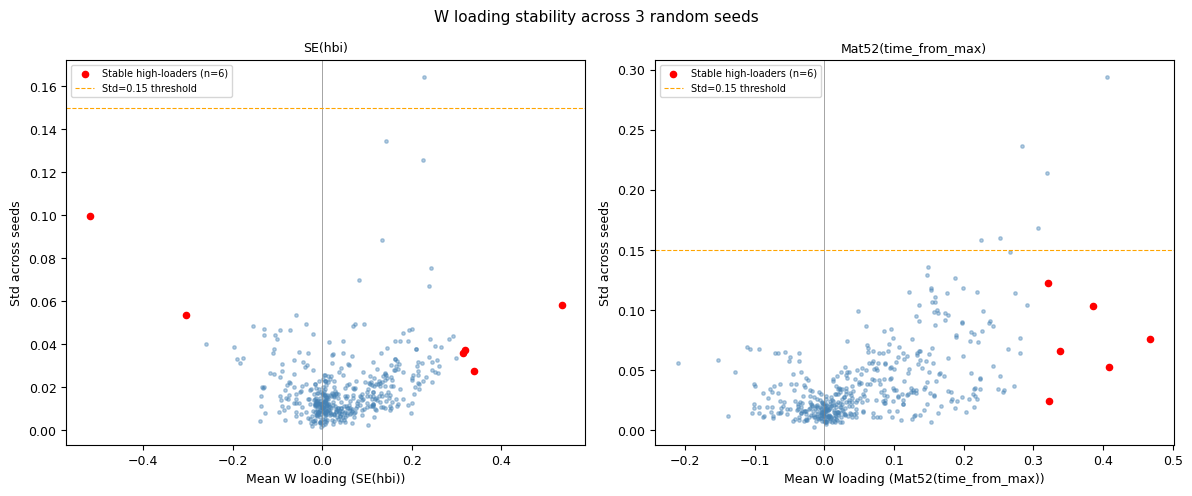

Saved stability results to multioutput/output/


In [44]:
# W Matrix Stability Check — 3 random seeds
# Expected runtime: ~2-3 hours total (50K iterations x 3 seeds).
# Results cached to stability_W_runs.pkl after first run.
# Each run uses full optimization settings matching the main fit.
# W is identified only up to column permutation and sign flip,
# so we align columns across runs before comparing.

from scipy.optimize import linear_sum_assignment
import pickle, os

SEEDS = [42, 1234, 9999]
STABILITY_CACHE = '../multioutput/output/stability_W_runs.pkl'

FIT_KWARGS = dict(
    penalization_factor=1.0,
    num_opt_iter=50000,
    adam_learning_rate=0.001,
    verbose=False,
    latent_kernels=latent_kernels,
)

if os.path.exists(STABILITY_CACHE):
    with open(STABILITY_CACHE, 'rb') as f:
        W_runs = pickle.load(f)
    print(f"Loaded {len(W_runs)} cached W runs")
else:
    W_runs = []
    for seed in SEEDS:
        print(f"=== Seed {seed} ===")
        _gps = GPSearch(
            X=mtd_sub,
            Y=mbx_sub,
            unit_col="participant_id",
            categorical_vars=["site_name", "race", "sex", "general_wellbeing"],
            outcome_likelihood="negativebinomial",
        )
        _gps.multioutput_penalized_optimization(random_seed=seed, **FIT_KWARGS)
        W_runs.append(_gps.models["multioutput"].kernel.W.numpy())
        print(f"Seed {seed}: W shape = {W_runs[-1].shape}")
    with open(STABILITY_CACHE, 'wb') as f:
        pickle.dump(W_runs, f)
    print(f"Saved to {STABILITY_CACHE}")


def align_W(W_ref, W_other):
    """Align W_other columns to W_ref via Hungarian algorithm + sign correction."""
    corr = np.corrcoef(W_ref.T, W_other.T)
    n = W_ref.shape[1]
    cost = -np.abs(corr[:n, n:])
    row_ind, col_ind = linear_sum_assignment(cost)
    W_aligned = W_other[:, col_ind]
    for k in range(n):
        if np.corrcoef(W_ref[:, k], W_aligned[:, k])[0, 1] < 0:
            W_aligned[:, k] *= -1
    return W_aligned, col_ind


# Use main fitted W as reference (seed from main fit)
W_ref = W.copy()
W_aligned = []
col_indices = []
for W_other in W_runs:
    W_al, col_idx = align_W(W_ref, W_other)
    W_aligned.append(W_al)
    col_indices.append(col_idx)

# Per-factor stability: correlation of each factor's loadings across runs
W_stack = np.stack(W_aligned, axis=0)  # (n_seeds, n_metabolites, n_factors)
print(f"=== Per-factor stability (correlation with main fit) ===")
print(f"{'Factor':<25}  " + "  ".join(f"seed={s}" for s in SEEDS) + "  mean_abs")
col_corrs = np.zeros((W_ref.shape[1], len(SEEDS)))
for j, W_al in enumerate(W_aligned):
    for k in range(W_ref.shape[1]):
        col_corrs[k, j] = np.corrcoef(W_ref[:, k], W_al[:, k])[0, 1]
for k in range(W_ref.shape[1]):
    vals = "  ".join(f"{col_corrs[k, j]:+.3f}" for j in range(len(SEEDS)))
    mean_abs = np.abs(col_corrs[k]).mean()
    label = kernel_labels[k] if k < len(kernel_labels) else str(k)
    print(f"{label:<25}  {vals}  {mean_abs:.3f}")

print(f"Overall mean abs correlation: {np.abs(col_corrs).mean():.3f}")
stable = (np.abs(col_corrs).mean(axis=1) >= 0.7).sum()
print(f"Factors with mean abs corr >= 0.7: {stable}/{W_ref.shape[1]}")

# Per-metabolite loading stability on SE(hbi) and Mat52(time_from_max)
hbi_idx_s  = kernel_labels.index('SE(hbi)')
tfm_idx_s  = kernel_labels.index('Mat52(time_from_max)')

W_hbi_runs  = np.stack([W_ref[:, hbi_idx_s]] + [W_al[:, hbi_idx_s] for W_al in W_aligned])
W_tfm_runs  = np.stack([W_ref[:, tfm_idx_s]] + [W_al[:, tfm_idx_s] for W_al in W_aligned])

hbi_mean  = W_hbi_runs.mean(axis=0)
hbi_std   = W_hbi_runs.std(axis=0)
tfm_mean  = W_tfm_runs.mean(axis=0)
tfm_std   = W_tfm_runs.std(axis=0)

# Coefficient of variation: std / |mean|, floored to avoid division by ~0
hbi_cv = hbi_std / (np.abs(hbi_mean) + 1e-6)
tfm_cv = tfm_std / (np.abs(tfm_mean) + 1e-6)

stability_df = pd.DataFrame({
    'metabolite': metabolite_names,
    'W_hbi_mean': hbi_mean,
    'W_hbi_std':  hbi_std,
    'W_hbi_cv':   hbi_cv,
    'W_tfm_mean': tfm_mean,
    'W_tfm_std':  tfm_std,
    'W_tfm_cv':   tfm_cv,
})
stability_df.to_csv('../multioutput/output/w_loading_stability.csv', index=False)

print(f"--- SE(hbi): top 15 stable high-loading metabolites (|mean| > 0.3, CV < 0.3) ---")
hbi_stable = stability_df[(stability_df['W_hbi_mean'].abs() > 0.3) & (stability_df['W_hbi_cv'] < 0.3)]
hbi_stable = hbi_stable.reindex(hbi_stable['W_hbi_mean'].abs().sort_values(ascending=False).index)
print(hbi_stable[['metabolite','W_hbi_mean','W_hbi_std','W_hbi_cv']].head(15).to_string(index=False))

print(f"--- Mat52(time_from_max): top 15 stable high-loading metabolites ---")
tfm_stable = stability_df[(stability_df['W_tfm_mean'].abs() > 0.3) & (stability_df['W_tfm_cv'] < 0.3)]
tfm_stable = tfm_stable.reindex(tfm_stable['W_tfm_mean'].abs().sort_values(ascending=False).index)
print(tfm_stable[['metabolite','W_tfm_mean','W_tfm_std','W_tfm_cv']].head(15).to_string(index=False))

# Visualization: scatter of mean W vs std for both factors
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, factor, mean_col, std_col, label in [
    (axes[0], 'SE(hbi)',            'W_hbi_mean', 'W_hbi_std', 'SE(hbi)'),
    (axes[1], 'Mat52(time_from_max)','W_tfm_mean', 'W_tfm_std', 'Mat52(time_from_max)'),
]:
    ax.scatter(stability_df[mean_col], stability_df[std_col],
               alpha=0.4, s=6, c='steelblue')
    # Highlight stable high-loaders
    mask = (stability_df[mean_col].abs() > 0.3) & (stability_df[std_col] < 0.15)
    ax.scatter(stability_df.loc[mask, mean_col], stability_df.loc[mask, std_col],
               c='red', s=20, zorder=5, label=f'Stable high-loaders (n={mask.sum()})')
    ax.set_xlabel(f'Mean W loading ({label})')
    ax.set_ylabel('Std across seeds')
    ax.set_title(label)
    ax.axvline(0, color='grey', lw=0.5)
    ax.axhline(0.15, color='orange', lw=0.8, linestyle='--', label='Std=0.15 threshold')
    ax.legend(fontsize=7)

plt.suptitle('W loading stability across 3 random seeds', fontsize=11)
plt.tight_layout()
plt.savefig('../multioutput/output/w_stability_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved stability results to multioutput/output/")


## Latent Factor Pruning via KL Gap Detection

Prune latent factors whose variational posterior has not meaningfully diverged from the prior. Rather than imposing an arbitrary fixed threshold on KL divergence (which is scale-dependent), we look for a natural gap in the sorted KL values — analogous to a scree plot elbow. Factors above the largest relative gap are retained; factors below are treated as uninformative and pruned.

In [8]:
# describe_kernel is now available as waveome._describe_kernel (used internally
# by model.plot_kl_scree and the kernel factor table below). Re-expose it here
# for use in the results section.
from waveome.model_classes import _describe_kernel

def describe_kernel(kern, feat_names):
    return _describe_kernel(kern, feat_names)

Smooth KL decay — all factors informative. No collapsed factors detected.


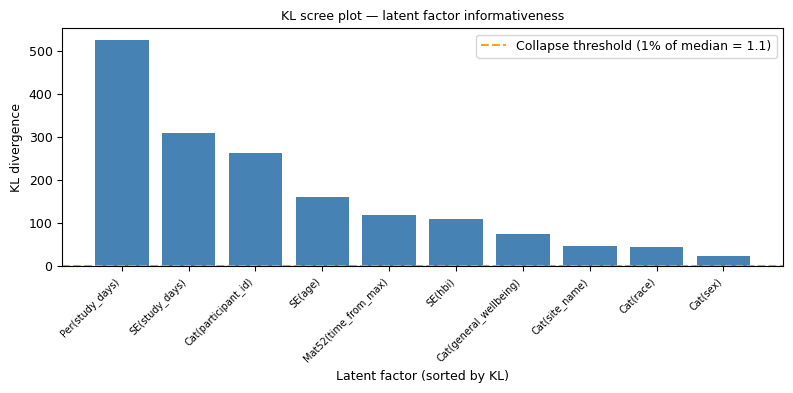

No latent factors pruned.
Final model: 10 active latent factors


In [9]:
model      = gps.models["multioutput"]
feat_names = list(gps.feat_names) if gps.feat_names is not None else []

fig, ax = plt.subplots(figsize=(8, 4))
kl_arr = model.plot_kl_scree(var_names=feat_names, ax=ax)
plt.tight_layout()
plt.show()

# Auto-prune collapsed factors (KL < 1% of median).
# If no factors are collapsed, the scree plot will show a smooth decay
# and no pruning is applied — all factors are retained as informative.
model.prune_latent_factors(kl_threshold=0.01, optimize_after_prune=True)
print(f"Final model: {model.kernel.W.numpy().shape[1]} active latent factors")

## Results

## Latent Factor Visualisation

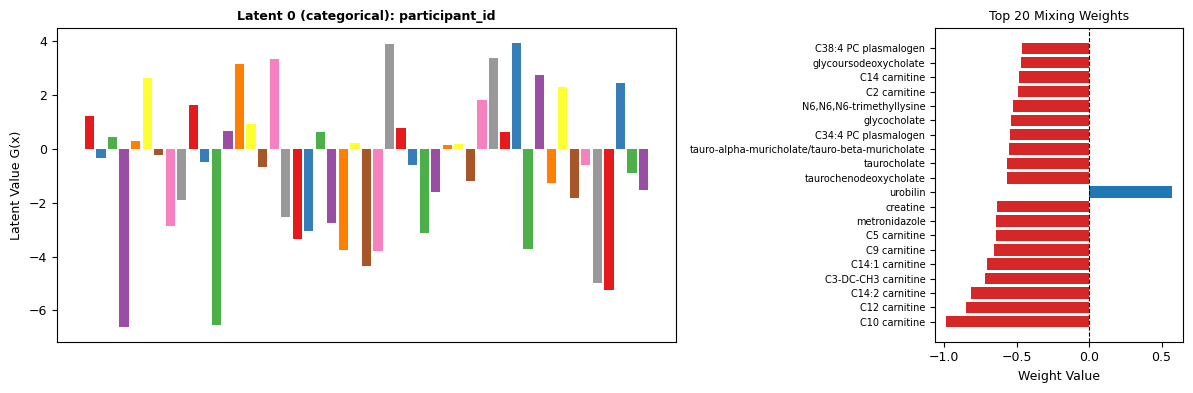

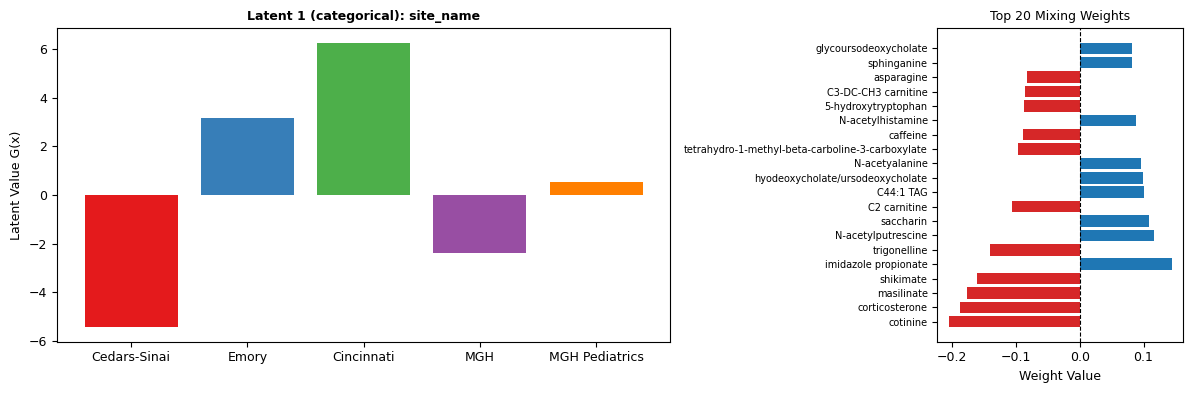

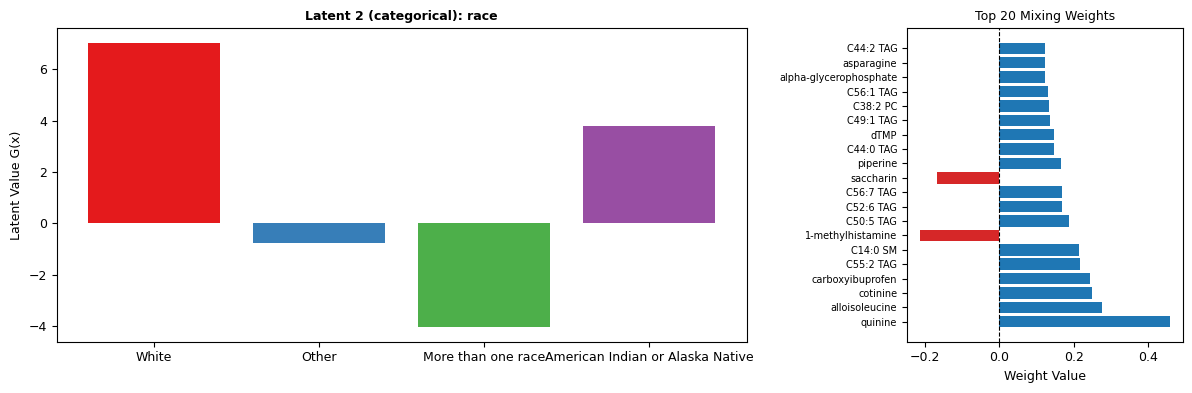

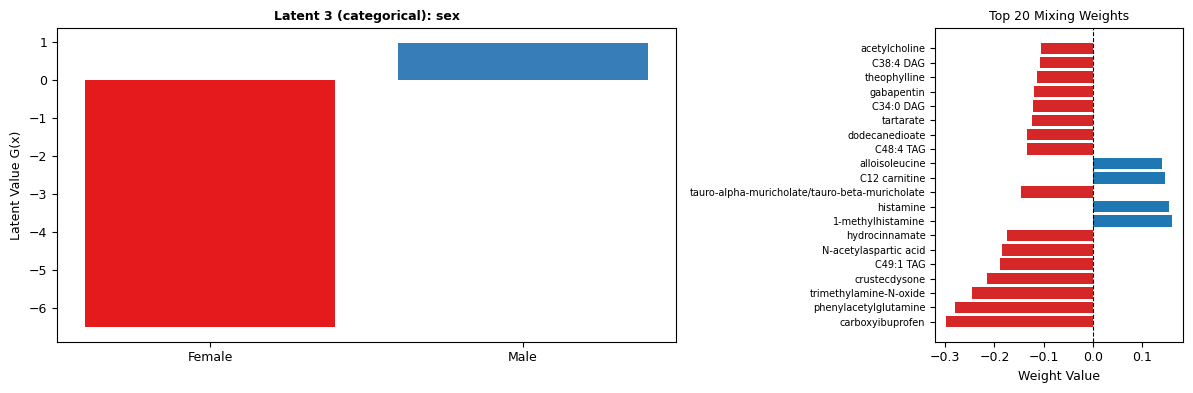

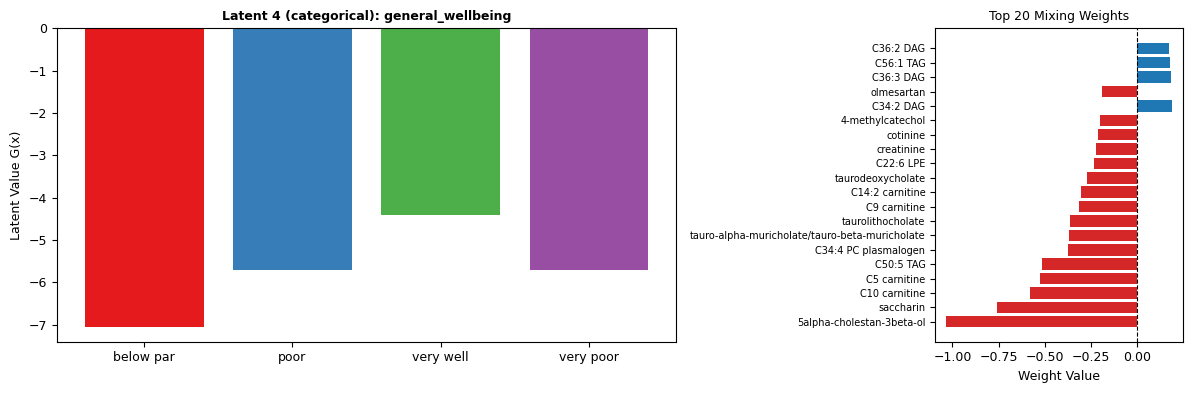

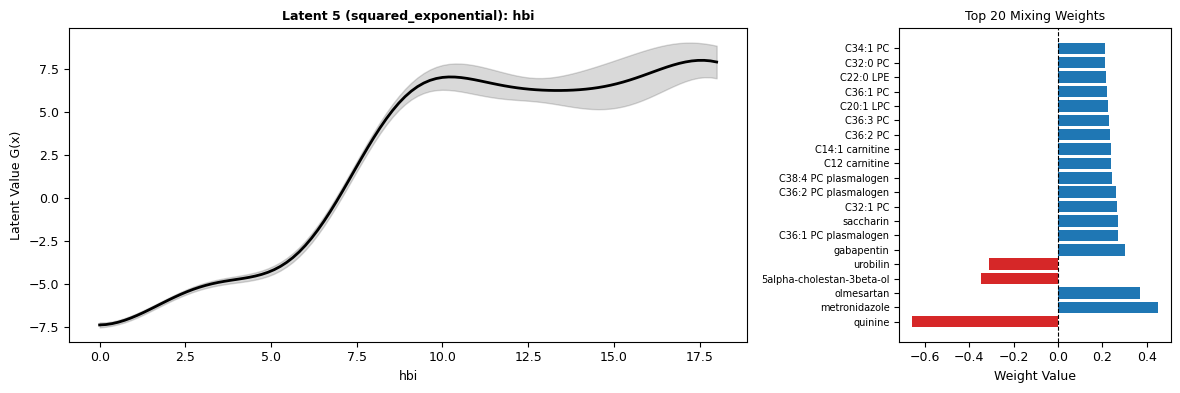

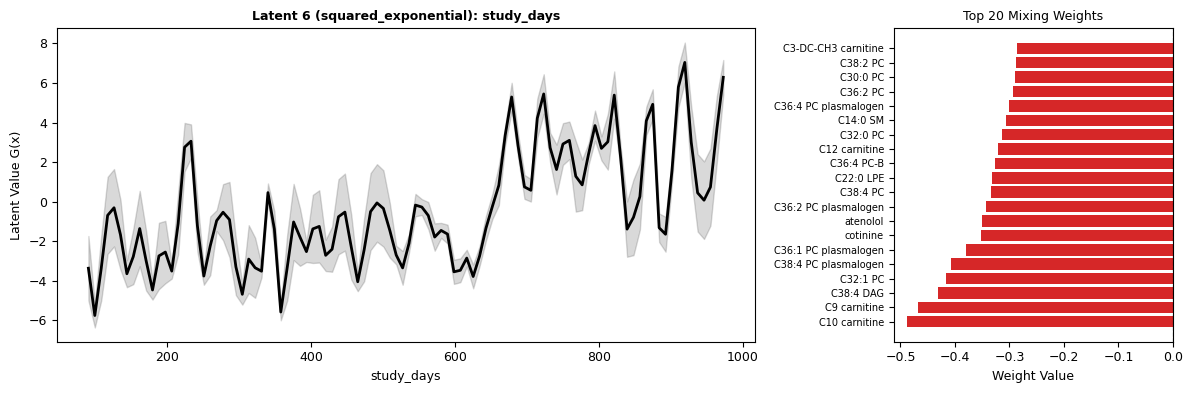

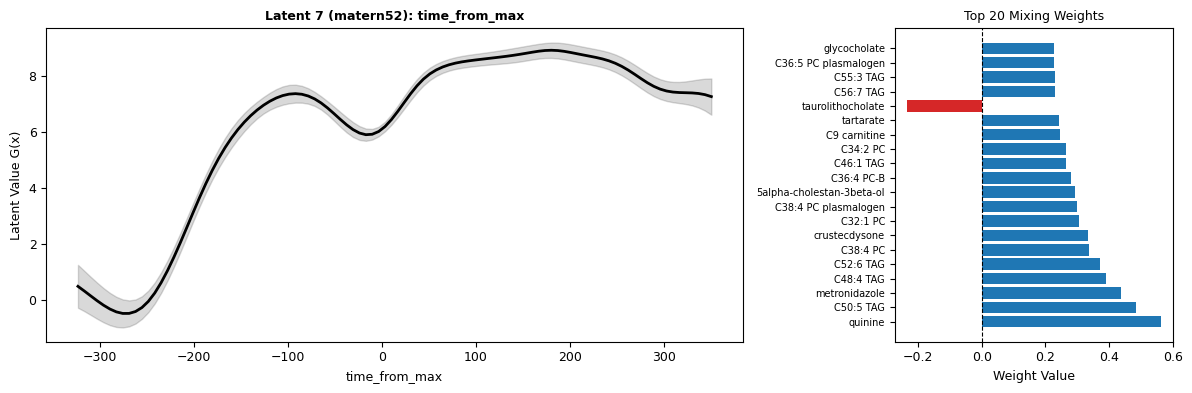

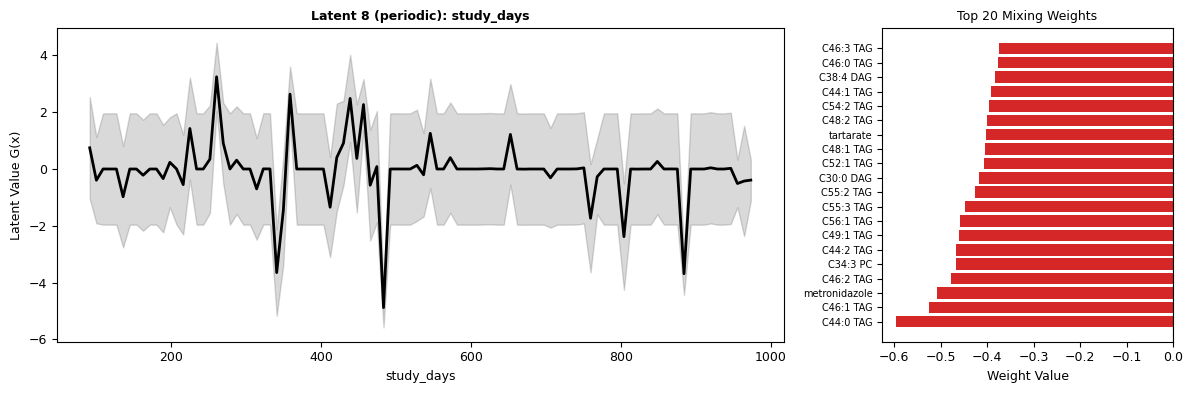

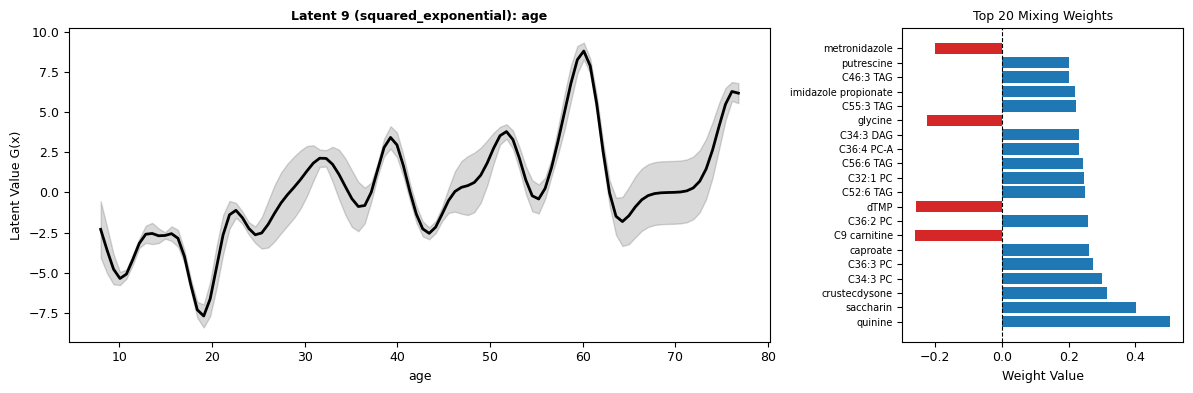

In [10]:
# Plot learned latent GP functions and their W loadings for all factors.
# Each panel shows the latent process f_k(x) as the covariate varies (left)
# and the distribution of W loadings across metabolites (right).
gps.plot_latent_processes(X_df=mtd_sub, top_n_weights=20)

In [11]:
# Extract W matrix (mixing weights)
model = gps.models["multioutput"]
W = model.kernel.W.numpy()
metabolite_names = list(mbx_sub.columns)
factor_names = [f"Factor {k+1}" for k in range(W.shape[1])]

W_df = pd.DataFrame(W, index=metabolite_names, columns=factor_names)
print(f"W matrix: {W_df.shape[0]} metabolites × {W_df.shape[1]} factors")
W_df.head(10)

W matrix: 459 metabolites × 10 factors


,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
12.13-diHOME,-0.070272,0.030995,-0.032967,0.044797,0.010872,0.004640,-0.058807,0.026698,-0.005770,0.053976
9.10-diHOME,-0.062170,0.015276,0.000227,0.042696,0.004060,0.022270,-0.024726,0.008520,0.002188,0.032138
caproate,0.102878,-0.027416,0.070063,0.025862,0.014276,-0.139229,-0.007289,0.122269,-0.001939,0.261437
hydrocinnamate,0.016158,0.029148,0.014647,-0.173720,-0.048881,-0.079758,-0.130794,-0.002127,-0.079674,0.036835
mandelate,-0.023849,0.043453,-0.034365,0.005369,-0.014559,0.024951,-0.072380,0.005966,-0.025531,0.076381
2-hydroxyoctanoate,0.002172,-0.037010,0.026608,-0.018032,0.020458,-0.022066,0.013326,-0.021581,-0.008624,0.000292
3-hydroxyoctanoate,-0.098298,0.057331,-0.020490,-0.028513,-0.024747,0.041851,-0.000472,0.009193,-0.022079,0.077184
caprate,0.080574,-0.021492,0.001925,0.040935,-0.022372,0.000963,-0.128761,0.142498,-0.202165,0.162302
indoleacetate,-0.044833,-0.008054,0.005283,-0.012054,0.048034,0.112770,-0.039074,0.147814,0.011437,0.063350
3-hydroxydecanoate,-0.099375,0.023689,0.018067,0.002759,0.020966,0.053879,-0.061377,0.000662,-0.053287,0.075754


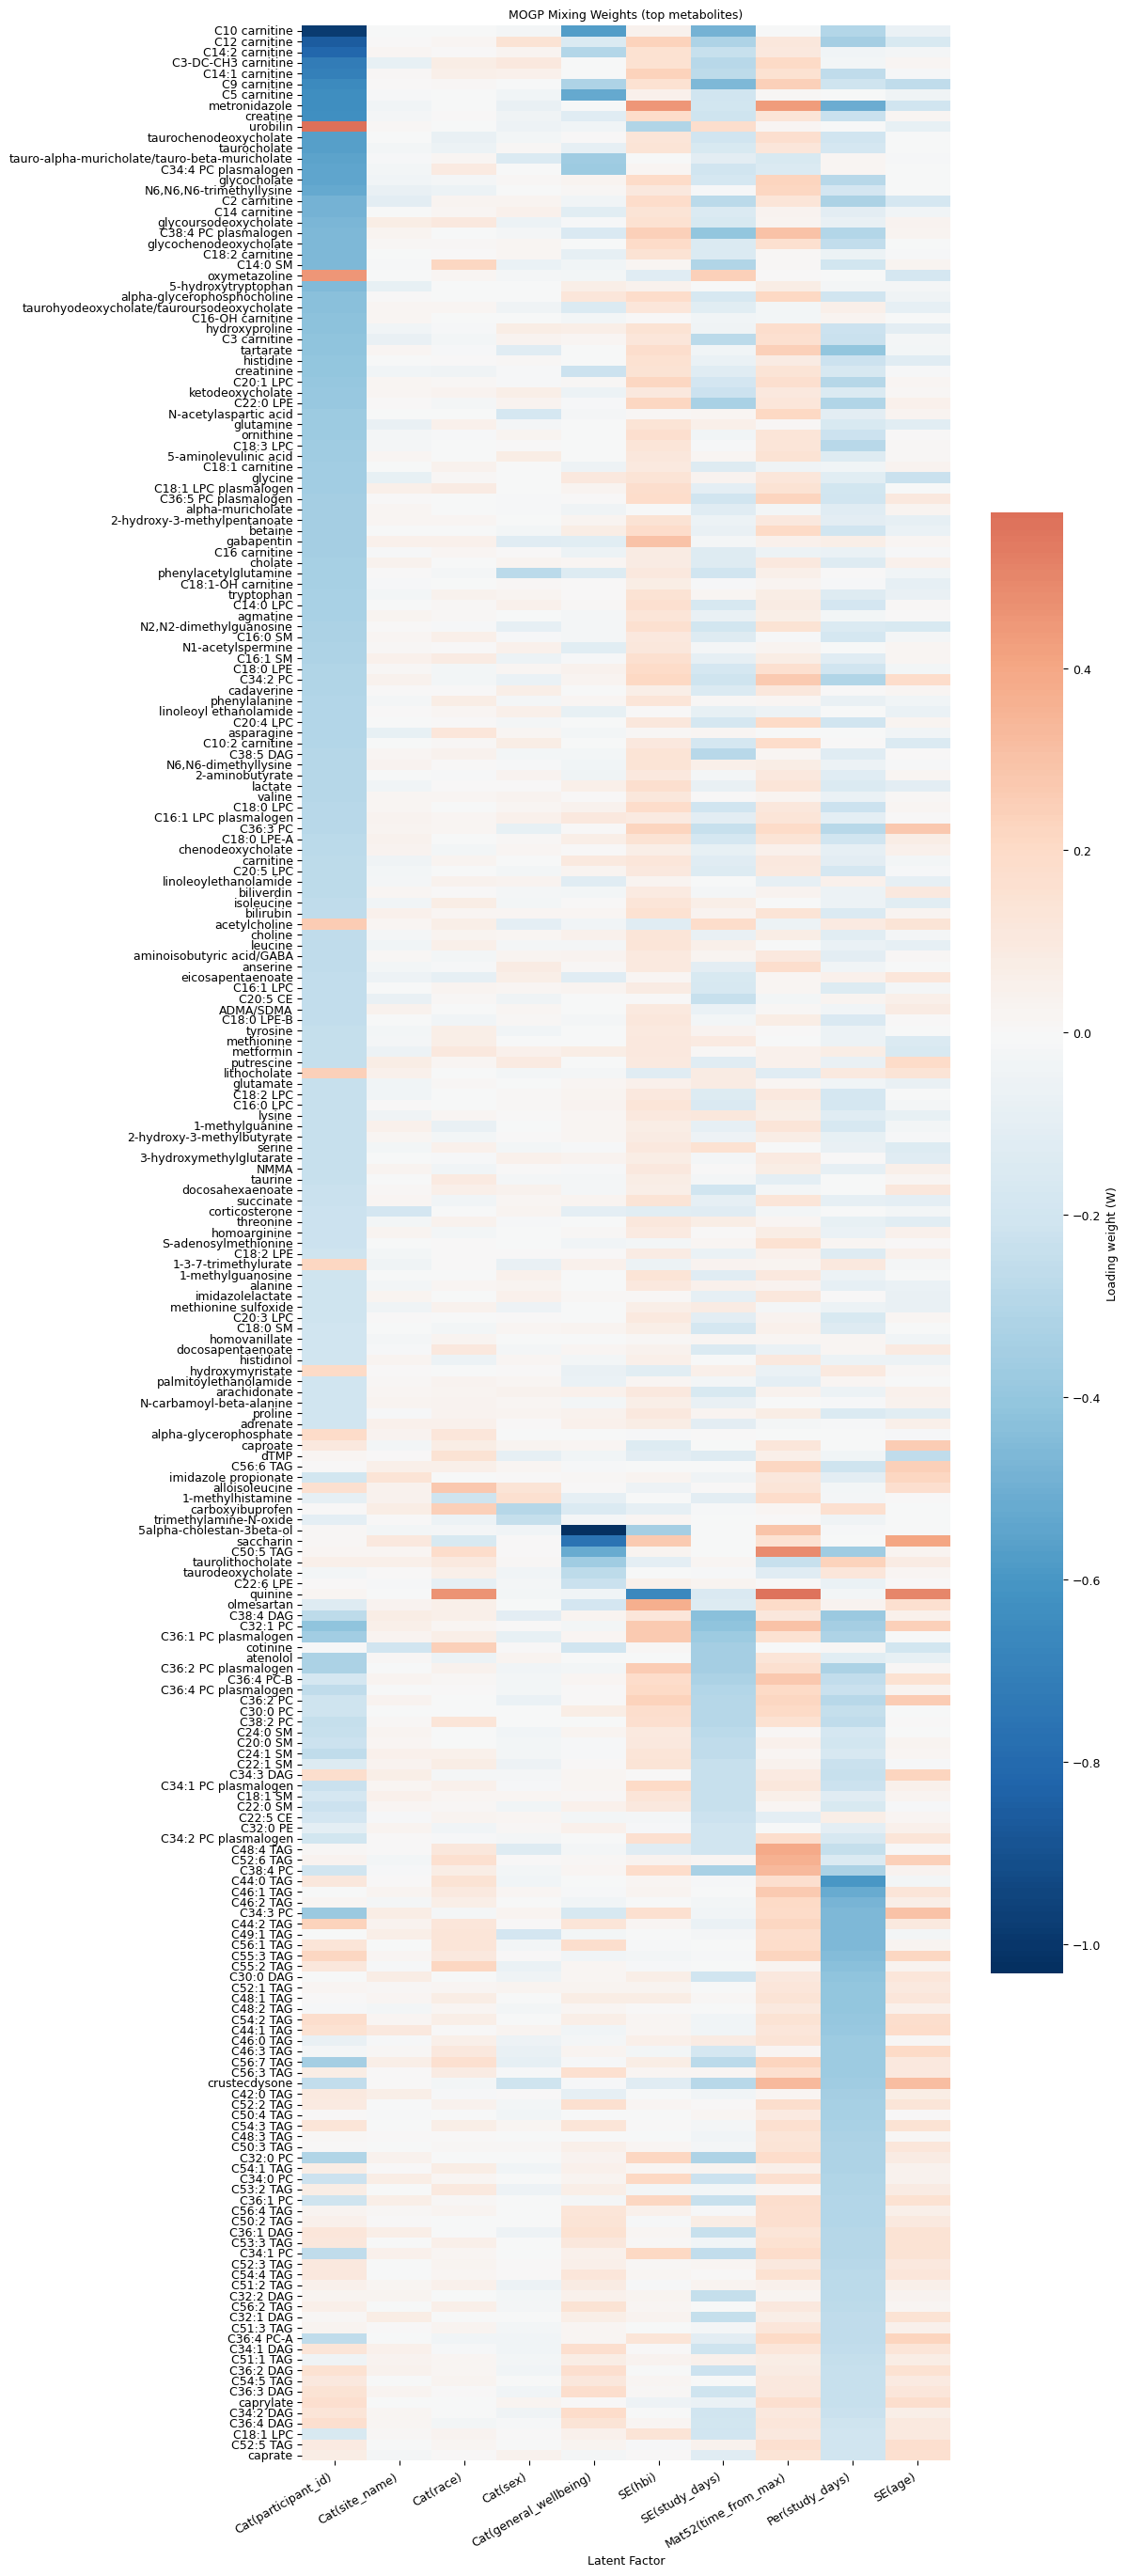

In [12]:
# Heatmap of W matrix (absolute values, top metabolites per factor)
abs_W = W_df.abs()

# Select top metabolites: those with max |W| > median across all factors
max_per_met = abs_W.max(axis=1)
top_mask = max_per_met > max_per_met.median()
W_top = W_df.loc[top_mask].copy()

# Sort by dominant factor for visual clarity
W_top["dominant_factor"] = abs_W.loc[top_mask].idxmax(axis=1)
W_top["max_loading"] = max_per_met.loc[top_mask]
W_top = W_top.sort_values(["dominant_factor", "max_loading"], ascending=[True, False])
W_plot = W_top.drop(columns=["dominant_factor", "max_loading"])

# Map Compound IDs to metabolite names where available
compound_to_name = dict(zip(mbx_lookup['Compound'], mbx_lookup['Metabolite']))
display_names = [compound_to_name.get(c, c) for c in W_plot.index]

# Build x-axis labels from kernel structure
feat_names_list = list(gps.feat_names) if gps.feat_names is not None else []
factor_labels = [
    describe_kernel(kern, feat_names_list)
    for kern in model.kernel.kernels
]

fig, ax = plt.subplots(figsize=(12, max(8, len(W_plot) * 0.12)))
sns.heatmap(
    W_plot.values,
    xticklabels=factor_labels,
    yticklabels=display_names,
    cmap="RdBu_r",
    center=0,
    ax=ax,
    cbar_kws={"label": "Loading weight (W)", "shrink": 0.6},
)
ax.set_xlabel("Latent Factor")
ax.set_ylabel("")
ax.set_title("MOGP Mixing Weights (top metabolites)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [13]:
# Extract module membership using Otsu thresholding
modules = model.get_module_membership(output_names=metabolite_names, method="otsu")

print(f"Discovered {len(modules)} modules:\n")
for factor_name, members in modules:
    named_members = [compound_to_name.get(m, m) for m in members]
    print(f"  {factor_name} ({len(members)} metabolites):")
    for m in named_members[:10]:
        print(f"    - {m}")
    if len(named_members) > 10:
        print(f"    ... and {len(named_members) - 10} more")
    print()

Discovered 10 modules:

  Factor_1 (126 metabolites):
    - eicosapentaenoate
    - docosahexaenoate
    - lithocholate
    - chenodeoxycholate
    - ketodeoxycholate
    - alpha-muricholate
    - cholate
    - glycochenodeoxycholate
    - glycoursodeoxycholate
    - glycocholate
    ... and 116 more

  Factor_2 (94 metabolites):
    - 3-hydroxyoctanoate
    - eicosapentaenoate
    - adrenate
    - oleanate
    - masilinate
    - lithocholate
    - deoxycholate
    - hyodeoxycholate/ursodeoxycholate
    - glycoursodeoxycholate
    - taurolithocholate
    ... and 84 more

  Factor_3 (55 metabolites):
    - eicosapentaenoate
    - docosapentaenoate
    - oleanate
    - glycoursodeoxycholate
    - taurolithocholate
    - taurochenodeoxycholate
    - saccharin
    - carboxyibuprofen
    - 1.2.3.4-tetrahydro-beta-carboline-1.3-dicarboxylate
    - C38:2 PC
    ... and 45 more

  Factor_4 (36 metabolites):
    - hydrocinnamate
    - dodecanedioate
    - tauro-alpha-muricholate/tauro-beta-muri

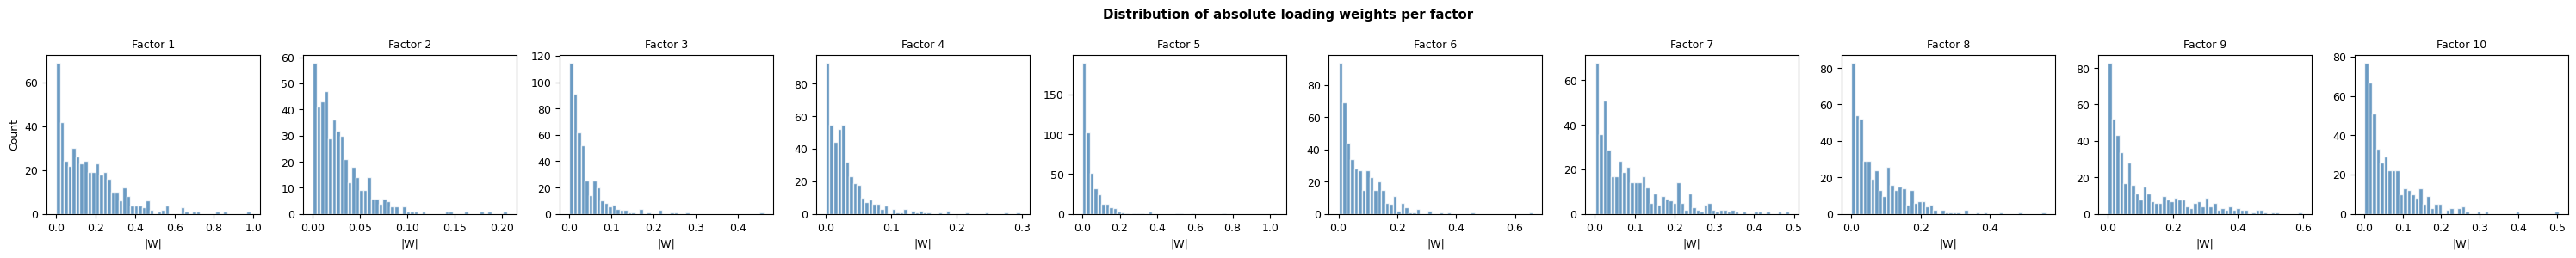

In [14]:
# Distribution of |W| per factor — shows signal/noise separation
fig, axes = plt.subplots(1, W.shape[1], figsize=(3 * W.shape[1], 3), squeeze=False)
for k in range(W.shape[1]):
    ax = axes[0, k]
    abs_w = np.abs(W[:, k])
    ax.hist(abs_w, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(f"Factor {k+1}")
    ax.set_xlabel("|W|")
    if k == 0:
        ax.set_ylabel("Count")
fig.suptitle("Distribution of absolute loading weights per factor", fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
W = gps.models["multioutput"].kernel.W.numpy()  # shape (n_metabolites, n_latents)

# Get the kernel descriptions to find the right column indices
feat = list(mtd_sub.columns)
latent_kernels = gps.models["multioutput"].kernel.kernels

kernel_labels = [_describe_kernel(k, feat) for k in latent_kernels]
print(list(enumerate(kernel_labels)))

hbi_idx = kernel_labels.index("SE(hbi)")
tfm_idx = kernel_labels.index("Mat52(time_from_max)")

w_hbi = W[:, hbi_idx]
w_tfm = W[:, tfm_idx]

corr = np.corrcoef(w_hbi, w_tfm)[0, 1]
print(f"W correlation between SE(hbi) and Mat52(time_from_max): {corr:.3f}")

# Also useful: absolute value correlation (sign is arbitrary)
corr_abs = np.corrcoef(np.abs(w_hbi), np.abs(w_tfm))[0, 1]
print(f"|W| correlation: {corr_abs:.3f}")


[(0, 'Cat(participant_id)'), (1, 'Cat(site_name)'), (2, 'Cat(race)'), (3, 'Cat(sex)'), (4, 'Cat(general_wellbeing)'), (5, 'SE(hbi)'), (6, 'SE(study_days)'), (7, 'Mat52(time_from_max)'), (8, 'Per(study_days)'), (9, 'SE(age)')]
W correlation between SE(hbi) and Mat52(time_from_max): 0.361
|W| correlation: 0.509


## Pathway Analysis

Evaluate the biological coherence of the MOGP latent factors using KEGG pathway annotations.

**Layer 1**: Pathway purity and hypergeometric enrichment per latent factor 
**Layer 2**: Annotation transfer to unlabeled metabolites using signed mixing weights

### Step 1: Build Metabolite → KEGG Pathway Mapping

In [16]:

# Load raw metabolomics data to get HMDB IDs
mbx_raw_full = pd.read_csv(
    '../examples/iHMP/data/iHMP_metabolomics.csv', index_col=0
)

# Build Metabolite -> HMDB ID lookup from raw data
hmdb_lookup = (
    mbx_raw_full[['Metabolite', 'HMDB (*Representative ID)']]
    .dropna(subset=['Metabolite'])
    .drop_duplicates(subset=['Metabolite'])
    .set_index('Metabolite')['HMDB (*Representative ID)']
    .str.strip().str.rstrip('*')
    .to_dict()
)

# Get deduplicated metabolite names from our fitted model
metabolite_names = list(mbx_sub.columns)
print(f"Metabolites in model: {len(metabolite_names)}")
print(f"Metabolites with HMDB IDs: {sum(1 for m in metabolite_names if hmdb_lookup.get(m))}")
print(f"Metabolites without HMDB IDs: {sum(1 for m in metabolite_names if not hmdb_lookup.get(m))}")


/var/folders/2w/r7x976td4f97twg4r5ff50500000gn/T/ipykernel_53000/3723618649.py:9: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  mbx_raw_full = pd.read_csv(


Metabolites in model: 459
Metabolites with HMDB IDs: 456
Metabolites without HMDB IDs: 3


### HMDB → KEGG Compound ID Mapping

In [17]:
import xml.etree.ElementTree as ET
import time
import os
import pandas as pd

def parse_hmdb_kegg_map(hmdb_xml_path):
    """
    Stream-parse HMDB metabolites XML to build:
      - hmdb_to_kegg: HMDB primary ID -> KEGG compound ID
      - hmdb_to_pathways: HMDB primary ID -> list of KEGG pathway IDs (hsa*)
      - secondary_to_primary: secondary accession -> primary accession
    Extracts pathway data directly from HMDB <pathways> section,
    avoiding the need for KEGG REST API calls.
    """
    NS = "http://www.hmdb.ca"
    hmdb_to_kegg = {}
    hmdb_to_pathways = {}
    secondary_to_primary = {}

    current_primary = None
    current_secondaries = []
    current_kegg = None
    current_pathways = []
    n = 0

    print("Parsing HMDB XML (this takes ~3-4 minutes)...")
    start = time.time()

    context = ET.iterparse(hmdb_xml_path, events=("start", "end"))
    for event, elem in context:
        tag = elem.tag.replace(f"{{{NS}}}", "")

        if event == "end" and tag == "metabolite":
            if current_primary:
                if current_kegg:
                    hmdb_to_kegg[current_primary] = current_kegg
                if current_pathways:
                    hmdb_to_pathways[current_primary] = list(set(current_pathways))
                for sec in current_secondaries:
                    secondary_to_primary[sec] = current_primary
            current_primary = None
            current_secondaries = []
            current_kegg = None
            current_pathways = []
            n += 1
            elem.clear()
            if n % 50000 == 0:
                print(f"  {n} metabolites processed ({time.time()-start:.0f}s)")

        elif event == "end" and tag == "accession":
            if current_primary is None:
                current_primary = elem.text
            elif elem.text:
                current_secondaries.append(elem.text)

        elif event == "end" and tag == "kegg_id":
            if elem.text and elem.text.startswith("C"):
                current_kegg = elem.text

        elif event == "end" and tag == "kegg_map_id":
            if elem.text and elem.text.startswith("map"):
                # Convert map00380 -> hsa00380
                current_pathways.append("hsa" + elem.text[3:])

    print(f"Done: {n} metabolites parsed in {time.time()-start:.0f}s")
    print(f"  HMDB->KEGG compound mappings: {len(hmdb_to_kegg)}")
    print(f"  HMDB->pathway mappings: {len(hmdb_to_pathways)}")
    return hmdb_to_kegg, hmdb_to_pathways, secondary_to_primary


def normalize_hmdb(hmdb_id):
    """Normalize 5- or 7-digit HMDB ID to 7-digit format."""
    if pd.isna(hmdb_id) or not hmdb_id:
        return None
    raw = str(hmdb_id).strip().rstrip("*")
    digits = raw[4:].zfill(7)
    return f"HMDB{digits}"


def lookup_pathways(hmdb_id, hmdb_to_pathways, secondary_to_primary):
    """Look up KEGG pathway IDs for a raw HMDB ID."""
    hid7 = normalize_hmdb(hmdb_id)
    if hid7 is None:
        return []
    pathways = hmdb_to_pathways.get(hid7, [])
    if not pathways:
        primary = secondary_to_primary.get(hid7)
        if primary:
            pathways = hmdb_to_pathways.get(primary, [])
    return pathways


def lookup_kegg(hmdb_id, hmdb_to_kegg, secondary_to_primary):
    """Look up KEGG compound ID for a raw HMDB ID."""
    hid7 = normalize_hmdb(hmdb_id)
    if hid7 is None:
        return None
    kegg = hmdb_to_kegg.get(hid7)
    if kegg is None:
        primary = secondary_to_primary.get(hid7)
        if primary:
            kegg = hmdb_to_kegg.get(primary)
    return kegg


# Parse HMDB XML (or load from cache)
kegg_cache_path = "../multioutput/output/metabolite_kegg_map.csv"
# HMDB XML file required for pathway mapping.
# Download from: https://hmdb.ca/system/downloads/current/hmdb_metabolites.zip
# (HMDB All Metabolites, ~1.5GB zip, ~6GB unzipped)
# Unzip and place at: examples/iHMP/data/hmdb_metabolites.xml
# File is not tracked in git due to size.
hmdb_xml_path = "../examples/iHMP/data/hmdb_metabolites.xml"

if os.path.exists(kegg_cache_path):
    kegg_map_df = pd.read_csv(kegg_cache_path)
    kegg_map_df["kegg_pathway_list"] = kegg_map_df["kegg_pathway_list"].apply(
        lambda x: x.split(";") if pd.notna(x) and x else []
    )
    print(f"Loaded cached KEGG mapping: {len(kegg_map_df)} metabolites")
else:
    hmdb_to_kegg, hmdb_to_pathways, secondary_to_primary = parse_hmdb_kegg_map(hmdb_xml_path)

    records = []
    for name in metabolite_names:
        hmdb_id = hmdb_lookup.get(name)
        kegg_id = lookup_kegg(hmdb_id, hmdb_to_kegg, secondary_to_primary)
        pathways = lookup_pathways(hmdb_id, hmdb_to_pathways, secondary_to_primary)
        records.append({
            "metabolite": name,
            "hmdb_id": hmdb_id,
            "kegg_compound_id": kegg_id,
            "kegg_pathway_list": ";".join(pathways),
        })

    kegg_map_df = pd.DataFrame(records)
    kegg_map_df.to_csv(kegg_cache_path, index=False)
    # Re-parse pathway list column as list
    kegg_map_df["kegg_pathway_list"] = kegg_map_df["kegg_pathway_list"].apply(
        lambda x: x.split(";") if pd.notna(x) and x else []
    )
    print(f"Saved to {kegg_cache_path}")

mapped_compounds = kegg_map_df["kegg_compound_id"].notna().sum()
mapped_pathways = kegg_map_df["kegg_pathway_list"].apply(len).gt(0).sum()
print(f"Mapped to KEGG compound ID: {mapped_compounds}/{len(kegg_map_df)} ({mapped_compounds/len(kegg_map_df):.1%})")
print(f"Mapped to >=1 KEGG pathway: {mapped_pathways}/{len(kegg_map_df)} ({mapped_pathways/len(kegg_map_df):.1%})")
print("Sample mappings:")
print(kegg_map_df[kegg_map_df["kegg_pathway_list"].apply(len).gt(0)].head(10)[["metabolite","hmdb_id","kegg_compound_id","kegg_pathway_list"]].to_string(index=False))


Loaded cached KEGG mapping: 459 metabolites
Mapped to KEGG compound ID: 302/459 (65.8%)
Mapped to >=1 KEGG pathway: 150/459 (32.7%)
Sample mappings:
       metabolite   hmdb_id kegg_compound_id                                  kegg_pathway_list
         caproate HMDB00535           C01585                                         [hsa01040]
          caprate HMDB00511           C01571                                         [hsa01040]
    indoleacetate HMDB00197           C00954                                         [hsa00380]
      dodecanoate HMDB00638           C02679                                         [hsa01040]
        palmitate HMDB00220           C00249 [hsa00120, hsa00071, hsa00100, hsa00561, hsa00062]
 alpha-linolenate HMDB01388           C06427                                         [hsa00592]
        linoleate HMDB00673           C01595                                         [hsa00592]
eicosapentaenoate HMDB01999           C06428                                       

### KEGG Compound → Pathway + Lipid Class Fallback

In [18]:
# Build pathway_map_df: HMDB pathways first, KEGG REST fallback, then lipid class regex
import re, time, requests

DRUG_PATTERNS = [
    'olmesartan', 'metformin', 'gabapentin', 'metronidazole',
    'ibuprofen', 'saccharin', 'saccharine', 'carboxyibuprofen',
    'cotinine', 'dTMP', 'crustecdysone',
]

LIPID_CLASS_PATHWAYS = {
    r'cholate|deoxycholate|lithocholate|ursodeoxycholate|muricholate': ['hsa00120', 'hsa00121'],
    r'\bTAG\b|\bDAG\b|\bMAG\b': ['hsa00561'],
    r'\bPC\b|\bLPC\b|\bLPE\b|\bPE\b|plasmalogen': ['hsa00564'],
    r'\bSM\b|sphingomyelin|\bCeramide\b': ['hsa00600'],
    r'carnitine': ['hsa00071'],
    r'\bCE\b|cholesterol ester': ['hsa00100'],
    r'diHOME|HODE|HETE|EpOME': ['hsa00590'],
    r'hydroxy\w+ate': ['hsa00071'],
    r'dioate$|dionate$|noate$|enoate$': ['hsa00071'],
}

def is_drug(name):
    return any(d.lower() in name.lower() for d in DRUG_PATTERNS)

def get_lipid_class_pathways(name):
    for pattern, pathways in LIPID_CLASS_PATHWAYS.items():
        if re.search(pattern, name, re.IGNORECASE):
            return pathways
    return []

def kegg_compound_to_pathways(kegg_id, retries=2):
    url = f"https://rest.kegg.jp/link/pathway/{kegg_id}"
    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=10)
            if resp.status_code != 200:
                return []
            return [
                line.split('	')[1].replace('path:', '')
                for line in resp.text.strip().split('')
                if '	' in line and line.split('	')[1].startswith('path:hsa')
            ]
        except Exception:
            time.sleep(1)
    return []


pathway_cache_path = '../multioutput/output/metabolite_pathway_map.csv'

if os.path.exists(pathway_cache_path):
    pathway_map_df = pd.read_csv(pathway_cache_path)
    pathway_map_df['kegg_pathway_list'] = pathway_map_df['kegg_pathway_list'].apply(
        lambda x: x.split(';') if pd.notna(x) and x else []
    )
    print(f"Loaded cached pathway mapping: {len(pathway_map_df)} metabolites")
else:
    # Fetch KEGG REST pathways for compounds that lack HMDB pathway annotations
    needs_kegg_api = kegg_map_df[
        kegg_map_df['kegg_compound_id'].notna() &
        kegg_map_df['kegg_pathway_list'].apply(len).eq(0)
    ]['kegg_compound_id'].unique()

    print(f"Fetching KEGG REST pathways for {len(needs_kegg_api)} compounds without HMDB annotations...")
    kegg_api_cache = {}
    for i, kegg_id in enumerate(needs_kegg_api):
        kegg_api_cache[kegg_id] = kegg_compound_to_pathways(kegg_id)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(needs_kegg_api)} processed...")
        time.sleep(0.2)

    records = []
    for _, row in kegg_map_df.iterrows():
        name = row['metabolite']
        drug = is_drug(name)
        hmdb_pathways = row['kegg_pathway_list']  # already a list

        if drug:
            pathways, source = [], 'drug'
        elif hmdb_pathways:
            pathways, source = hmdb_pathways, 'hmdb'
        elif pd.notna(row.get('kegg_compound_id')):
            pathways = kegg_api_cache.get(row['kegg_compound_id'], [])
            source = 'kegg_api' if pathways else 'lipid_class'
            if not pathways:
                pathways = get_lipid_class_pathways(name)
        else:
            pathways = get_lipid_class_pathways(name)
            source = 'lipid_class' if pathways else 'unmapped'

        records.append({
            'metabolite': name,
            'kegg_compound_id': row.get('kegg_compound_id'),
            'kegg_pathway_list': pathways,
            'is_drug': drug,
            'mapping_source': source,
        })

    pathway_map_df = pd.DataFrame(records)
    save_df = pathway_map_df.copy()
    save_df['kegg_pathway_list'] = save_df['kegg_pathway_list'].apply(lambda x: ';'.join(x))
    save_df.to_csv(pathway_cache_path, index=False)
    print(f"Saved to {pathway_cache_path}")

src_counts = pathway_map_df['mapping_source'].value_counts()
print("Mapping source breakdown:")
print(src_counts.to_string())
labeled = pathway_map_df['kegg_pathway_list'].apply(len).gt(0)
print(f"Metabolites with >=1 KEGG pathway: {labeled.sum()} ({labeled.mean():.1%})")


Loaded cached pathway mapping: 459 metabolites
Mapping source breakdown:
mapping_source
lipid_class    269
hmdb           149
unmapped        31
drug            10
Metabolites with >=1 KEGG pathway: 328 (71.5%)


### Build `metabolite_df` for Pathway Evaluation

In [19]:
# Build the metabolite_df required by the evaluation framework
W = gps.models["multioutput"].kernel.W.numpy()
metabolite_names = list(mbx_sub.columns)

metabolite_df = pathway_map_df.rename(columns={'metabolite': 'metabolite_id'}).copy()
metabolite_df['name'] = metabolite_df['metabolite_id']
metabolite_df['is_labeled'] = metabolite_df['kegg_pathway_list'].apply(lambda x: len(x) > 0)
metabolite_df['_true_pathway_list'] = metabolite_df['kegg_pathway_list']

# Reorder to match W matrix row order
metabolite_df = metabolite_df.set_index('metabolite_id').loc[metabolite_names].reset_index()

print(f"metabolite_df shape: {metabolite_df.shape}")
print(f"Labeled (has pathway): {metabolite_df['is_labeled'].sum()} ({metabolite_df['is_labeled'].mean():.1%})")
print(f"Unlabeled: {(~metabolite_df['is_labeled']).sum()}")
print(f"Drugs excluded: {metabolite_df['is_drug'].sum()}")
metabolite_df.head()


metabolite_df shape: (459, 8)
Labeled (has pathway): 328 (71.5%)
Unlabeled: 131
Drugs excluded: 10


,metabolite_id,kegg_compound_id,kegg_pathway_list,is_drug,mapping_source,name,is_labeled,_true_pathway_list
0,12.13-diHOME,C14829,[hsa00590],False,lipid_class,12.13-diHOME,True,[hsa00590]
1,9.10-diHOME,NaN,[hsa00590],False,lipid_class,9.10-diHOME,True,[hsa00590]
2,caproate,C01585,[hsa01040],False,hmdb,caproate,True,[hsa01040]
3,hydrocinnamate,C05629,[],False,lipid_class,hydrocinnamate,False,[]
4,mandelate,C01984,[],False,lipid_class,mandelate,False,[]


### Fetch KEGG Pathway Labels

In [20]:
# Get human-readable KEGG pathway names
all_pathway_ids = set(
    p for pathways in metabolite_df['kegg_pathway_list'] for p in pathways
)
print(f"Unique KEGG pathways represented: {len(all_pathway_ids)}")

pathway_labels_cache = '../multioutput/output/kegg_pathway_labels.csv'

if os.path.exists(pathway_labels_cache):
    pw_label_df = pd.read_csv(pathway_labels_cache)
    pathway_labels = dict(zip(pw_label_df['pathway_id'], pw_label_df['pathway_name']))
else:
    pathway_labels = {}
    for pid in all_pathway_ids:
        url = f"https://rest.kegg.jp/get/{pid}"
        try:
            resp = requests.get(url, timeout=10)
            if resp.status_code == 200:
                match = re.search(r'^NAME\s+(.+)', resp.text, re.MULTILINE)
                if match:
                    pathway_labels[pid] = match.group(1).strip().rstrip(' - Homo sapiens (human)')
        except Exception:
            pass
        time.sleep(0.2)
    
    pd.DataFrame(
        {'pathway_id': list(pathway_labels.keys()),
         'pathway_name': list(pathway_labels.values())}
    ).to_csv(pathway_labels_cache, index=False)

print(f"Pathway labels fetched: {len(pathway_labels)}")
print("\nExample pathways:")
for pid, name in list(pathway_labels.items())[:10]:
    print(f"  {pid}: {name}")


Unique KEGG pathways represented: 50
Pathway labels fetched: 48

Example pathways:
  hsa00430: Taurine and hypotaurine metabol
  hsa00232: Caffeine metabol
  hsa00590: Arachidonic acid metabol
  hsa00250: Alanine, aspartate and glutamate metabol
  hsa00052: Galactose metabol
  hsa00740: Riboflavin metabol
  hsa00592: alpha-Linolenic acid metabol
  hsa00830: Retinol metabol
  hsa00260: Glycine, serine and threonine metabol
  hsa00020: Citrate cycle (TCA cycl


### Step 2: Layer 1 — Pathway Coherence

For each latent factor, compute weighted pathway purity and hypergeometric enrichment using labeled metabolites (those with known KEGG pathway annotations).

In [21]:
import gseapy as gp
from collections import defaultdict

def compute_weighted_pathway_purity(weight_matrix, metabolite_df):
    labeled_mask = metabolite_df['is_labeled'].values & ~metabolite_df['is_drug'].values
    labeled_weights = weight_matrix[labeled_mask]
    labeled_df = metabolite_df[labeled_mask].reset_index(drop=True)
    purity_records = []
    for c in range(weight_matrix.shape[1]):
        abs_weights = np.abs(labeled_weights[:, c])
        total_weight = abs_weights.sum()
        if total_weight < 1e-6:
            continue
        pathway_weights = defaultdict(float)
        for i, w in enumerate(abs_weights):
            for pathway in labeled_df.iloc[i]['kegg_pathway_list']:
                pathway_weights[pathway] += w
        if not pathway_weights:
            continue
        dominant_pathway = max(pathway_weights, key=pathway_weights.get)
        purity_records.append({
            'cluster': c,
            'purity': pathway_weights[dominant_pathway] / total_weight,
            'dominant_pathway': dominant_pathway,
            'dominant_pathway_name': pathway_labels.get(dominant_pathway, dominant_pathway),
        })
    return pd.DataFrame(purity_records)


def run_gsea_per_factor(weight_matrix, metabolite_df, metabolite_names,
                        kernel_labels, signed=False, permutation_num=1000, seed=42):
    """
    Run gseapy prerank GSEA for each latent factor independently.

    signed=False (default): rank by |W|, tests for any strong association
    signed=True: rank by signed W, detects directional enrichment
    """
    pathway_sets = defaultdict(list)
    for _, row in metabolite_df.iterrows():
        for p in row['kegg_pathway_list']:
            pathway_sets[p].append(row['metabolite_id'])

    results = []
    for c, label in enumerate(kernel_labels):
        scores = weight_matrix[:, c]
        if not signed:
            scores = np.abs(scores)
        rnk = pd.Series(scores, index=metabolite_names).sort_values(ascending=False)
        rnk_df = rnk.reset_index()
        rnk_df.columns = ['metabolite', 'score']
        try:
            res = gp.prerank(
                rnk=rnk_df,
                gene_sets=dict(pathway_sets),
                threads=1,
                outdir=None,
                min_size=3,
                max_size=500,
                permutation_num=permutation_num,
                seed=seed,
                verbose=False,
            )
            df = res.res2d.copy()
            df['cluster'] = c
            df['kernel_label'] = label
            df['pathway_name'] = df['Term'].map(pathway_labels).fillna(df['Term'])
            df = df.rename(columns={
                'Term': 'pathway', 'NOM p-val': 'p_value', 'FDR q-val': 'FDR',
                'NES': 'NES', 'ES': 'ES', 'Tag %': 'tag_pct',
            })
            results.append(df[['cluster', 'kernel_label', 'pathway', 'pathway_name',
                                'ES', 'NES', 'p_value', 'FDR', 'tag_pct']])
        except Exception as e:
            print(f"  GSEA failed for {label}: {e}")
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


from waveome.model_classes import _describe_kernel
feat = list(mtd_sub.columns)
latent_kernels = gps.models["multioutput"].kernel.kernels
kernel_labels = [_describe_kernel(k, feat) for k in latent_kernels]

purity_df = compute_weighted_pathway_purity(W, metabolite_df)
purity_df['kernel_label'] = purity_df['cluster'].map(dict(enumerate(kernel_labels)))
print("Pathway purity per latent factor (diagnostic):")
print(purity_df[['kernel_label', 'purity', 'dominant_pathway_name']].to_string(index=False))


Pathway purity per latent factor (diagnostic):
          kernel_label   purity       dominant_pathway_name
   Cat(participant_id) 0.214122 Glycerophospholipid metabol
        Cat(site_name) 0.199560        Glycerolipid metabol
             Cat(race) 0.306681        Glycerolipid metabol
              Cat(sex) 0.227757        Glycerolipid metabol
Cat(general_wellbeing) 0.280738        Glycerolipid metabol
               SE(hbi) 0.309704 Glycerophospholipid metabol
        SE(study_days) 0.273829 Glycerophospholipid metabol
  Mat52(time_from_max) 0.293492        Glycerolipid metabol
       Per(study_days) 0.430463        Glycerolipid metabol
               SE(age) 0.271486        Glycerolipid metabol


In [22]:
print("Running GSEA with absolute |W| loadings...")
gsea_abs_df = run_gsea_per_factor(W, metabolite_df, metabolite_names,
                                   kernel_labels, signed=False, permutation_num=1000)
gsea_abs_df.to_csv('../multioutput/output/mogp_gsea_absolute.csv', index=False)

sig_abs = gsea_abs_df[gsea_abs_df['FDR'] < 0.25].sort_values(['kernel_label', 'FDR'])
print(f"\nSignificant factor-pathway pairs (FDR < 0.25): {len(sig_abs)}")
print(sig_abs[['kernel_label', 'pathway_name', 'NES', 'p_value', 'FDR', 'tag_pct']].to_string(index=False))

print("\n--- SE(hbi) all pathways ---")
hbi = gsea_abs_df[gsea_abs_df['kernel_label'] == 'SE(hbi)'].sort_values('p_value')
print(hbi[['pathway_name', 'NES', 'p_value', 'FDR']].head(15).to_string(index=False))

print("\n--- Mat52(time_from_max) all pathways ---")
tfm = gsea_abs_df[gsea_abs_df['kernel_label'] == 'Mat52(time_from_max)'].sort_values('p_value')
print(tfm[['pathway_name', 'NES', 'p_value', 'FDR']].head(15).to_string(index=False))


Running GSEA with absolute |W| loadings...

Significant factor-pathway pairs (FDR < 0.25): 18
        kernel_label                           pathway_name       NES   p_value       FDR tag_pct
 Cat(participant_id)                               hsa00121  1.714809       0.0  0.013451     5/6
 Cat(participant_id)              Primary bile acid biosynt   1.64658       0.0  0.025867   11/22
 Cat(participant_id)            Glycerophospholipid metabol   1.58623       0.0  0.044491   38/50
 Cat(participant_id)                    Fatty acid degradat  1.571277       0.0  0.044491   15/42
           Cat(race)                       Pyruvate metabol -1.480128  0.030973  0.042959     3/3
           Cat(race)                      Porphyrin metabol -1.495768  0.042735  0.079952     5/5
            Cat(sex)                      Histidine metabol  1.561079   0.01153  0.224185     3/9
            Cat(sex)                       Caffeine metabol   1.51206  0.015766  0.228779     4/5
Mat52(time_from_max)    

In [23]:
print("Running GSEA with signed W loadings...")
gsea_signed_df = run_gsea_per_factor(W, metabolite_df, metabolite_names,
                                      kernel_labels, signed=True, permutation_num=1000)
gsea_signed_df.to_csv('../multioutput/output/mogp_gsea_signed.csv', index=False)

sig_signed = gsea_signed_df[gsea_signed_df['FDR'] < 0.25].sort_values(['kernel_label', 'FDR'])
print(f"\nSignificant factor-pathway pairs (FDR < 0.25): {len(sig_signed)}")
print(sig_signed[['kernel_label', 'pathway_name', 'NES', 'p_value', 'FDR']].to_string(index=False))

print("\n--- SE(hbi) signed ---")
hbi_s = gsea_signed_df[gsea_signed_df['kernel_label'] == 'SE(hbi)'].sort_values('p_value')
print(hbi_s[['pathway_name', 'NES', 'p_value', 'FDR']].head(15).to_string(index=False))

print("\n--- Mat52(time_from_max) signed ---")
tfm_s = gsea_signed_df[gsea_signed_df['kernel_label'] == 'Mat52(time_from_max)'].sort_values('p_value')
print(tfm_s[['pathway_name', 'NES', 'p_value', 'FDR']].head(15).to_string(index=False))

print("\n--- Agreement between absolute and signed (FDR < 0.25) ---")
abs_sig_set = set(zip(sig_abs['kernel_label'], sig_abs['pathway']))
signed_sig_set = set(zip(sig_signed['kernel_label'], sig_signed['pathway']))
both = abs_sig_set & signed_sig_set
abs_only = abs_sig_set - signed_sig_set
signed_only = signed_sig_set - abs_sig_set
print(f"Both: {len(both)}, Absolute only: {len(abs_only)}, Signed only: {len(signed_only)}")


Running GSEA with signed W loadings...

Significant factor-pathway pairs (FDR < 0.25): 58
          kernel_label                             pathway_name       NES   p_value       FDR
Cat(general_wellbeing)                     Glycerolipid metabol  1.954946       0.0       0.0
Cat(general_wellbeing)                          Steroid biosynt  1.638799  0.012531  0.064015
   Cat(participant_id)                     Glycerolipid metabol  2.746065       0.0       0.0
   Cat(participant_id)                         Caffeine metabol  1.914353  0.009709  0.008327
   Cat(participant_id)                                 hsa00121  -1.69583       0.0  0.008609
   Cat(participant_id)                      Fatty acid degradat -1.676351       0.0  0.010402
   Cat(participant_id)              Glycerophospholipid metabol -1.650587  0.001006  0.012644
   Cat(participant_id)                Primary bile acid biosynt -1.707164       0.0  0.015065
             Cat(race)                        Histidine metabol 

/var/folders/2w/r7x976td4f97twg4r5ff50500000gn/T/ipykernel_53000/3007726215.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot = gsea_signed_df[gsea_signed_df['pathway'].isin(sig_pathways)].pivot_table(
/var/folders/2w/r7x976td4f97twg4r5ff50500000gn/T/ipykernel_53000/3007726215.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = gsea_signed_df[gsea_signed_df['pathway'].isin(sig_pathways)].pivot_table(


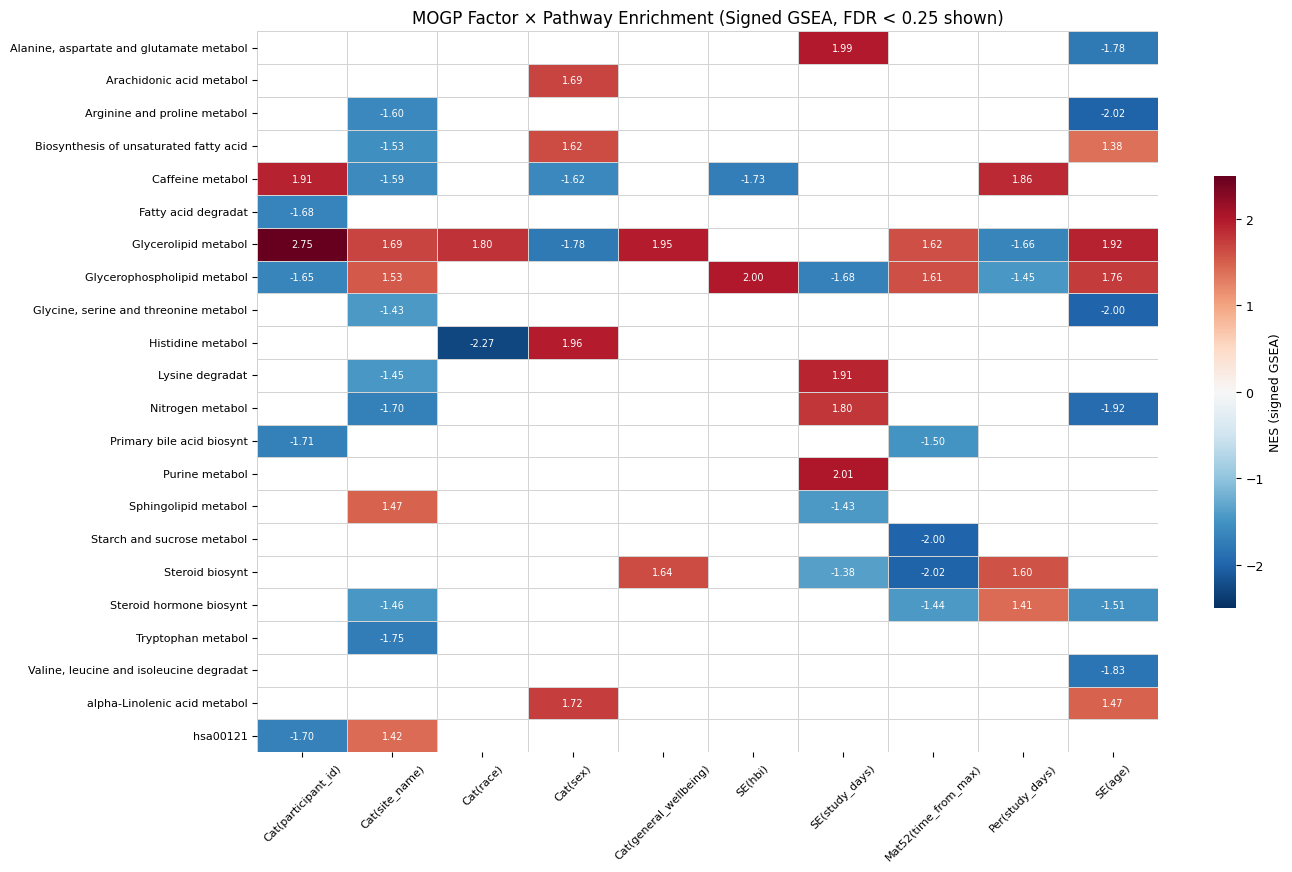

Heatmap saved. 22 significant pathways x 10 factors shown.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# NES heatmap: factors x pathways, signed GSEA results
# Only show pathways significant (FDR < 0.25) in at least one factor
sig_pathways = gsea_signed_df[gsea_signed_df['FDR'] < 0.25]['pathway'].unique()
pivot = gsea_signed_df[gsea_signed_df['pathway'].isin(sig_pathways)].pivot_table(
    index='pathway_name', columns='kernel_label', values='NES', fill_value=0
)

# Reorder columns by kernel label order
col_order = [l for l in kernel_labels if l in pivot.columns]
pivot = pivot[col_order]

# Mask non-significant cells (FDR >= 0.25)
sig_mask = gsea_signed_df[gsea_signed_df['pathway'].isin(sig_pathways)].pivot_table(
    index='pathway_name', columns='kernel_label', values='FDR', fill_value=1.0
)
sig_mask = sig_mask[col_order]
mask = sig_mask >= 0.25

fig, ax = plt.subplots(figsize=(14, max(8, len(pivot) * 0.4)))
sns.heatmap(
    pivot, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-2.5, vmax=2.5,
    linewidths=0.5, linecolor='lightgrey',
    cbar_kws={'label': 'NES (signed GSEA)', 'shrink': 0.6},
    annot=True, fmt='.2f', annot_kws={'size': 7},
)
ax.set_title('MOGP Factor × Pathway Enrichment (Signed GSEA, FDR < 0.25 shown)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('../multioutput/output/mogp_gsea_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Heatmap saved. {len(sig_pathways)} significant pathways x {len(col_order)} factors shown.")


### Step 3: Layer 2 — Annotation Transfer to Unlabeled Metabolites

For each unlabeled metabolite, propagate KEGG pathway annotations from its cluster's significant enrichments, weighted by the signed mixing weight. Negative weights indicate counter-regulatory association.

Precision-Recall at different confidence thresholds:
 threshold  precision   recall   n
      0.00   0.307927 1.000000 328
      0.05   0.307927 1.000000 328
      0.10   0.311728 0.987805 324
      0.15   0.392241 0.707317 232
      0.20   0.608696 0.280488  92
      0.25   0.692308 0.039634  13
      0.30        NaN 0.000000   0
      0.35        NaN 0.000000   0
      0.40        NaN 0.000000   0
      0.45        NaN 0.000000   0
      0.50        NaN 0.000000   0
      0.55        NaN 0.000000   0
      0.60        NaN 0.000000   0
      0.65        NaN 0.000000   0
      0.70        NaN 0.000000   0
      0.75        NaN 0.000000   0
      0.80        NaN 0.000000   0


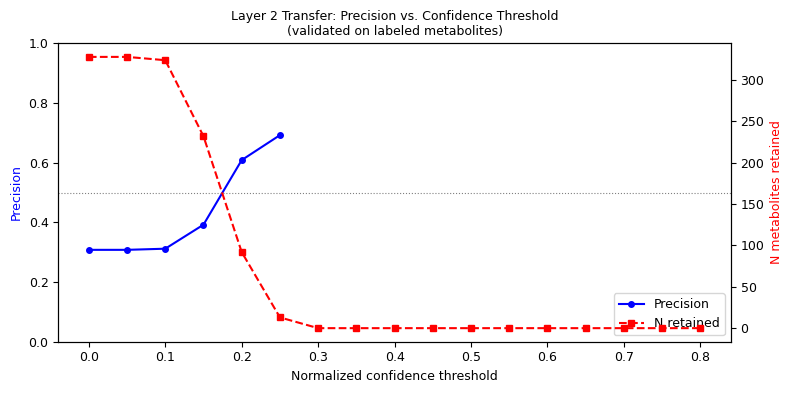

In [25]:
### Layer 2 Validation: Precision-Recall on Labeled Metabolites

# Run transfer on labeled metabolites as if they were unlabeled,
# then compare predicted pathway to true pathway membership.
# A prediction is "correct" if the predicted pathway is in the metabolite's true pathway list.

def validate_transfer(weight_matrix, metabolite_df, gsea_df, fdr_cutoff=0.25):
    labeled_mask = metabolite_df['is_labeled'].values & ~metabolite_df['is_drug'].values
    labeled_indices = np.where(labeled_mask)[0]

    sig = gsea_df[gsea_df['FDR'] < fdr_cutoff].copy()
    cluster_to_pathways = defaultdict(list)
    for _, row in sig.iterrows():
        cluster_to_pathways[int(row['cluster'])].append(
            (row['pathway'], float(row['NES']))
        )

    records = []
    for idx in labeled_indices:
        weights = weight_matrix[idx]
        true_pathways = set(metabolite_df.iloc[idx]['kegg_pathway_list'])

        pathway_scores = defaultdict(float)
        for c in range(weight_matrix.shape[1]):
            w = weights[c]
            if np.abs(w) < 1e-6:
                continue
            for (pathway, nes) in cluster_to_pathways[c]:
                pathway_scores[pathway] += w * nes

        if not pathway_scores:
            continue

        top_pathway = max(pathway_scores, key=lambda p: abs(pathway_scores[p]))
        top_score = pathway_scores[top_pathway]
        total_abs = sum(abs(v) for v in pathway_scores.values())
        norm_conf = abs(top_score) / total_abs if total_abs > 0 else 0.0
        correct = top_pathway in true_pathways

        records.append({
            'metabolite_id': metabolite_df.iloc[idx]['metabolite_id'],
            'true_pathways': true_pathways,
            'predicted_pathway': top_pathway,
            'correct': correct,
            'normalized_confidence': norm_conf,
        })

    val_df = pd.DataFrame(records)

    # Precision-recall at different confidence thresholds
    thresholds = np.arange(0.0, 0.81, 0.05)
    pr_records = []
    for t in thresholds:
        above = val_df[val_df['normalized_confidence'] >= t]
        precision = above['correct'].mean() if len(above) > 0 else np.nan
        recall = len(above) / len(val_df)
        pr_records.append({'threshold': t, 'precision': precision,
                           'recall': recall, 'n': len(above)})
    pr_df = pd.DataFrame(pr_records)

    print("Precision-Recall at different confidence thresholds:")
    print(pr_df.to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()
    ax.plot(pr_df['threshold'], pr_df['precision'], 'b-o', label='Precision', ms=4)
    ax2.plot(pr_df['threshold'], pr_df['recall'] * len(val_df), 'r--s',
             label='N retained', ms=4)
    ax.set_xlabel('Normalized confidence threshold')
    ax.set_ylabel('Precision', color='b')
    ax2.set_ylabel('N metabolites retained', color='r')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
    ax.set_title('Layer 2 Transfer: Precision vs. Confidence Threshold\n(validated on labeled metabolites)')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
    plt.tight_layout()
    plt.savefig('../multioutput/output/layer2_validation.png', dpi=150, bbox_inches='tight')
    plt.show()

    return val_df, pr_df

val_df, pr_df = validate_transfer(W, metabolite_df, gsea_signed_df)


In [26]:
def transfer_pathway_annotations(weight_matrix, metabolite_df, gsea_df, fdr_cutoff=0.25):
    """
    For each unlabeled metabolite, predict pathway membership by propagating
    signed GSEA enrichment scores from significantly enriched factors.

    score(metabolite i, pathway P) = sum_c W[i,c] * NES[c,P]
    where the sum is over factors where pathway P is significant (FDR < fdr_cutoff).
    """
    sig = gsea_df[gsea_df['FDR'] < fdr_cutoff].copy()
    cluster_to_pathways = defaultdict(list)
    for _, row in sig.iterrows():
        cluster_to_pathways[int(row['cluster'])].append(
            (row['pathway'], float(row['NES']))
        )

    unlabeled_mask = ~metabolite_df['is_labeled'].values | metabolite_df['is_drug'].values
    unlabeled_indices = np.where(unlabeled_mask)[0]
    n_clusters = weight_matrix.shape[1]
    records = []

    for idx in unlabeled_indices:
        weights = weight_matrix[idx]
        pathway_scores = defaultdict(float)
        for c in range(n_clusters):
            w = weights[c]
            if np.abs(w) < 1e-6:
                continue
            for (pathway, nes) in cluster_to_pathways[c]:
                pathway_scores[pathway] += w * nes

        if not pathway_scores:
            top_pathway, top_score = 'Unassigned', 0.0
        else:
            top_pathway = max(pathway_scores, key=lambda p: abs(pathway_scores[p]))
            top_score = pathway_scores[top_pathway]

        total_abs = sum(abs(v) for v in pathway_scores.values())
        norm_score = abs(top_score) / total_abs if total_abs > 0 else 0.0

        records.append({
            'metabolite_id': metabolite_df.iloc[idx]['metabolite_id'],
            'predicted_pathway': top_pathway,
            'predicted_pathway_name': pathway_labels.get(top_pathway, top_pathway),
            'transfer_score': top_score,
            'normalized_confidence': norm_score,
            'top_factor': kernel_labels[int(np.argmax(np.abs(weights)))],
            'top_factor_weight': float(weights[np.argmax(np.abs(weights))]),
        })

    transfer_df = pd.DataFrame(records)
    assigned = transfer_df['predicted_pathway'] != 'Unassigned'
    print(f"Unlabeled metabolites:  {len(transfer_df)}")
    print(f"Assigned to pathway:    {assigned.sum()} ({assigned.mean():.1%})")
    print(f"Unassigned:             {(~assigned).sum()}")
    print()
    print("Top predicted pathway assignments:")
    print(transfer_df[assigned].sort_values('normalized_confidence', ascending=False)
          [['metabolite_id', 'predicted_pathway_name', 'transfer_score',
            'normalized_confidence', 'top_factor']].head(20).to_string(index=False))
    return transfer_df


transfer_df = transfer_pathway_annotations(W, metabolite_df, gsea_signed_df)


Unlabeled metabolites:  131
Assigned to pathway:    131 (100.0%)
Unassigned:             0

Top predicted pathway assignments:
            metabolite_id      predicted_pathway_name  transfer_score  normalized_confidence             top_factor
5alpha-cholestan-3beta-ol             Steroid biosynt       -2.294095               0.343633 Cat(general_wellbeing)
   palmithoylethanolamide        Glycerolipid metabol       -0.799710               0.280989    Cat(participant_id)
    linoleoylethanolamide        Glycerolipid metabol       -1.405562               0.261555    Cat(participant_id)
                 piperine           Histidine metabol       -0.427665               0.257903              Cat(race)
         cinnamoylglycine        Glycerolipid metabol       -0.426025               0.241924 Cat(general_wellbeing)
    palmitoylethanolamide        Glycerolipid metabol       -0.859228               0.235588    Cat(participant_id)
   linoleoyl ethanolamide        Glycerolipid metabol       -

In [27]:
# Save results
gsea_abs_df.to_csv('../multioutput/output/mogp_gsea_absolute.csv', index=False)
gsea_signed_df.to_csv('../multioutput/output/mogp_gsea_signed.csv', index=False)
transfer_df.to_csv('../multioutput/output/mogp_pathway_transfer.csv', index=False)
purity_df.to_csv('../multioutput/output/mogp_pathway_purity.csv', index=False)
print("Saved GSEA results to multioutput/output/")


Saved GSEA results to multioutput/output/


In [28]:
## Tier 3: Projection of Unnamed Metabolic Features

# Load raw metabolomics, filter to unnamed features, apply QC filter
CV_THRESHOLD = 0.3

raw = pd.read_csv('../examples/iHMP/data/iHMP_metabolomics.csv', low_memory=False)
named_mask = raw['Metabolite'].notna() & (raw['Metabolite'].str.strip() != '')
unnamed_raw = raw[~named_mask].copy()

# Parse CV and apply quality filter
unnamed_raw['_cv'] = pd.to_numeric(unnamed_raw['Pooled QC sample CV'], errors='coerce')
n_total = len(unnamed_raw)
n_missing_cv = unnamed_raw['_cv'].isna().sum()
n_high_cv = (unnamed_raw['_cv'] > CV_THRESHOLD).sum()
unnamed_filt = unnamed_raw[unnamed_raw['_cv'] <= CV_THRESHOLD].copy()

print(f"Unnamed features total:              {n_total:>6}")
print(f"  Dropped (CV missing):              {n_missing_cv:>6}")
print(f"  Dropped (CV > {CV_THRESHOLD}):           {n_high_cv:>6}")
print(f"  Retained (CV <= {CV_THRESHOLD}):          {len(unnamed_filt):>6}")

# Sample columns — same as used in model fitting
sample_cols = [c for c in raw.columns if c not in
               ['Method','Pooled QC sample CV','m/z','RT',
                'HMDB (*Representative ID)','Metabolite','Compound']]

# Align to samples used in model (mbx_sub columns = model sample IDs)
model_samples = list(mbx_sub.index)
available = [s for s in model_samples if s in unnamed_filt.columns]
missing_samples = [s for s in model_samples if s not in unnamed_filt.columns]
print(f"\nModel samples:       {len(model_samples)}")
print(f"  Found in raw data: {len(available)}")
print(f"  Missing:           {len(missing_samples)}")

# Build Y_unnamed: shape (n_samples, n_unnamed_features)
# Rows = samples (aligned to model), cols = unnamed features
Y_unnamed = unnamed_filt.set_index('Compound')[available].T
Y_unnamed = Y_unnamed.reindex(model_samples)  # align row order to model
Y_unnamed = np.log1p(Y_unnamed.apply(pd.to_numeric, errors='coerce').fillna(0).values)

# Feature metadata
unnamed_meta = unnamed_filt[['Compound','m/z','RT','Method','_cv']].copy()
unnamed_meta = unnamed_meta.rename(columns={'_cv': 'cv'}).reset_index(drop=True)

print(f"\nY_unnamed shape: {Y_unnamed.shape}  (samples × features)")
print(f"Memory: {Y_unnamed.nbytes / 1e6:.1f} MB")


Unnamed features total:               81271
  Dropped (CV missing):                3950
  Dropped (CV > 0.3):            35354
  Retained (CV <= 0.3):           41967

Model samples:       238
  Found in raw data: 238
  Missing:           0

Y_unnamed shape: (238, 41967)  (samples × features)
Memory: 79.9 MB


In [36]:
## Project Unnamed Features onto Fitted Latent Space

model = gps.models["multioutput"]
n_factors = W.shape[1]

# Get Fmu: posterior latent mean, shape (n_samples, n_metabolites)
Fmu, _ = model.predict_f(model.data[0])
Fmu = Fmu.numpy()

# Back out H from Fmu: H = Fmu @ W @ inv(W.T @ W)
# Valid because only 2.77% of Fmu variance lies outside W's column space (SVGP approximation)
WtW = W.T @ W
H = Fmu @ W @ np.linalg.inv(WtW)  # (n_samples, n_factors)
print(f"H shape: {H.shape}  (n_samples x n_factors)")

# Reconstruction check (per-column R², correct formula)
Fmu_hat = H @ W.T
ss_res = np.sum((Fmu - Fmu_hat) ** 2, axis=0)
ss_tot = np.sum((Fmu - Fmu.mean(axis=0)) ** 2, axis=0)
r2_per_met = 1 - ss_res / (ss_tot + 1e-10)
print(f"Reconstruction R² on named metabolites: mean={r2_per_met.mean():.3f}, median={np.median(r2_per_met):.3f}")

# --- Prepare unnamed features in latent f space ---
# NB likelihood: mu_j = exp(f_j + offset_j), offset_j = log(median(Y_j))
# So f_j ≈ log(Y_j) - offset_j = log(Y_j) - log(median(Y_j)) = log(Y_j / median(Y_j))
# Y_unnamed was log1p-transformed in the load cell; undo that and re-center by log-median

# Y_unnamed is log1p(raw_counts): shape (n_samples, n_unnamed)
Y_raw = np.expm1(Y_unnamed)  # back to counts

# Per-feature offset: log(median), floored at 1 to avoid log(0)
col_medians = np.maximum(np.median(Y_raw, axis=0), 1.0)
offsets_unnamed = np.log(col_medians)  # (n_unnamed,)

# f_unnamed ≈ log(Y_raw + 1) - offsets_unnamed  (matching model's parameterization)
F_unnamed = np.log1p(Y_raw) - offsets_unnamed[np.newaxis, :]  # (n_samples, n_unnamed)

print(f"\nF_unnamed shape: {F_unnamed.shape}  (offset-centered log counts)")
print(f"F_unnamed mean: {F_unnamed.mean():.4f}  (should be ~0 after offset centering)")
print(f"Fmu mean:       {Fmu.mean():.4f}  (reference)")

# OLS projection
HtH = H.T @ H
HtF = H.T @ F_unnamed
W_unnamed = np.linalg.solve(HtH, HtF).T  # (n_unnamed, n_factors)

# Per-feature R² in f space
F_pred = H @ W_unnamed.T
ss_res = np.sum((F_unnamed - F_pred) ** 2, axis=0)
ss_tot = np.sum((F_unnamed - F_unnamed.mean(axis=0)) ** 2, axis=0)
r2 = 1 - ss_res / (ss_tot + 1e-10)

print(f"\nW_unnamed shape: {W_unnamed.shape}")
print(f"\nR² distribution across unnamed features (f space):")
for t in [0.0, 0.1, 0.2, 0.3, 0.5]:
    n = (r2 >= t).sum()
    print(f"  R² >= {t}: {n} ({n/len(r2):.1%})")


H shape: (238, 10)  (n_samples x n_factors)
Reconstruction R² on named metabolites: mean=0.289, median=0.847

F_unnamed shape: (238, 41967)  (offset-centered log counts)
F_unnamed mean: -0.1391  (should be ~0 after offset centering)
Fmu mean:       0.8776  (reference)

W_unnamed shape: (41967, 10)

R² distribution across unnamed features (f space):
  R² >= 0.0: 41964 (100.0%)
  R² >= 0.1: 32201 (76.7%)
  R² >= 0.2: 15024 (35.8%)
  R² >= 0.3: 5237 (12.5%)
  R² >= 0.5: 251 (0.6%)


Likelihood type: NegativeBinomialPerOutput
Could not extract per-likelihood offsets: 'NegativeBinomialPerOutput' object has no attribute 'likelihoods'
Single offset: [14.17464687 14.08794777  7.04009847 10.98985855  8.77384889 12.47579439
  8.41438497 10.43943984  9.41841089 12.97324253 13.49451228 11.81555649
 11.11980139 15.41824968 15.16212446 17.81394733 10.37514606 15.93688428
 17.42943898 10.31891949 13.79395387 14.5548913  16.38776795 18.52625076
 18.57353724 15.87815646 10.95163953 13.33523192 10.87161143 10.41132873
 13.68478152 16.35722491 16.21712119 14.57238601 14.7459586  12.91912661
 11.72921357 14.94469974 15.40584618 15.25051818 13.0723335   9.10375689
 14.84309022 12.84822649 17.08252529 15.87891881 18.09025496 15.64094317
 14.40792456 14.91783844 16.27373291 11.27913797 14.4700788  13.78324405
 11.70603034 14.14051479 12.50797192 14.58181363 13.98878212 12.65625933
 10.68620118 14.6123148  10.5730334  13.63079293  9.9591824  13.93816615
 12.53824816  6.33150185  7.913

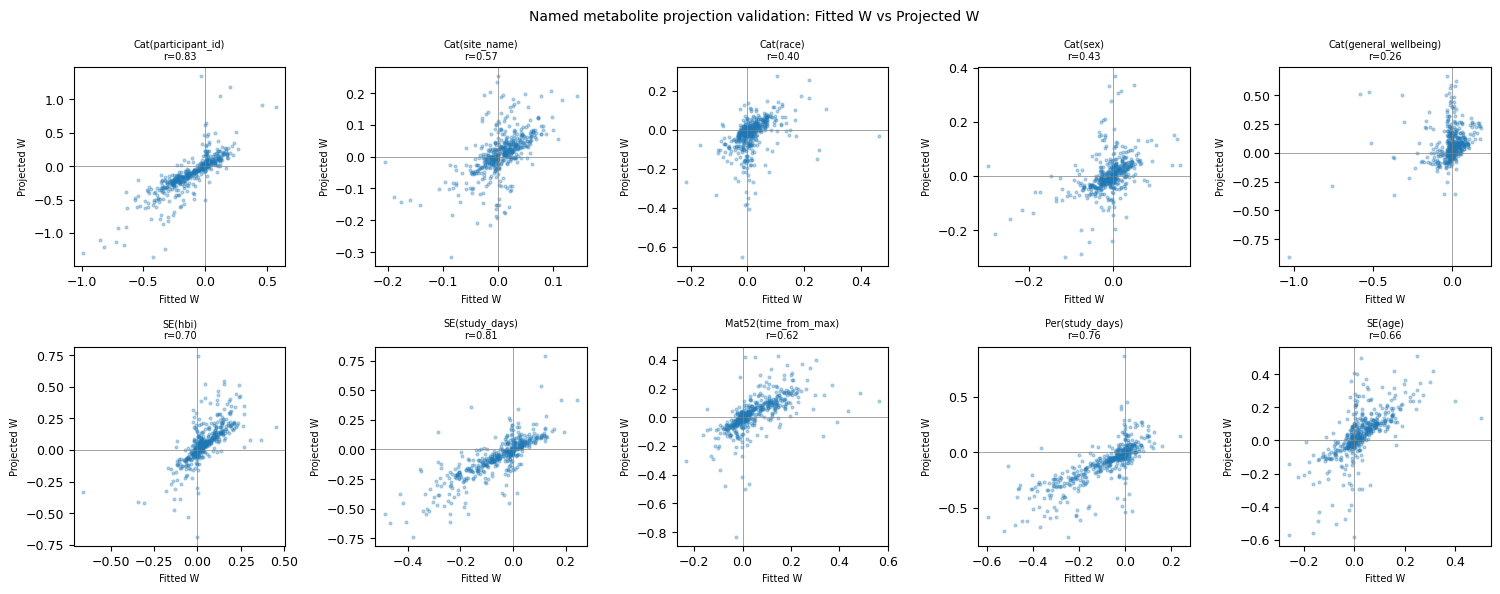

In [38]:
## Validate Projection: Named Metabolites as Ground Truth

# Extract learned per-output offsets from the likelihood
# NegativeBinomialPerOutput stores offset as a trainable parameter per metabolite
lik = gps.models['multioutput'].likelihood
print(f"Likelihood type: {type(lik).__name__}")

# Try to get per-output offsets
try:
    # For NegativeBinomialPerOutput likelihood stored as list
    offsets_learned = np.array([float(l.offset) for l in lik.likelihoods])
    print(f"Learned offsets shape: {offsets_learned.shape}")
    print(f"Learned offsets mean: {offsets_learned.mean():.4f}")
except Exception as e:
    print(f"Could not extract per-likelihood offsets: {e}")
    # Fallback: use single learned offset if available
    try:
        offsets_learned = np.array(lik.offset)
        print(f"Single offset: {offsets_learned}")
    except:
        offsets_learned = None
        print("No offset found, using mean gap correction")

# Apply learned offsets to get F in model's latent space
Y_named_raw = mbx_sub.values  # raw counts
if offsets_learned is not None and len(offsets_learned) == Y_named_raw.shape[1]:
    F_named = np.log1p(Y_named_raw) - offsets_learned[np.newaxis, :]
else:
    # Fallback: use mean gap from Fmu
    col_medians = np.maximum(np.median(Y_named_raw, axis=0), 1.0)
    F_named = np.log1p(Y_named_raw) - np.log(col_medians)[np.newaxis, :]

print(f"\nF_named mean (with learned offsets): {F_named.mean():.4f}")
print(f"Fmu mean:                             {Fmu.mean():.4f}")
print(f"Residual gap:                         {Fmu.mean() - F_named.mean():.4f}  (should be ~0)")

# Project named metabolites
W_proj_named = np.linalg.solve(HtH, H.T @ F_named).T  # (n_metabolites, n_factors)

from scipy.stats import pearsonr
print(f"\nCorrelation between projected W and fitted W per factor:")
print(f"{'Factor':<25} {'r':>8} {'p-value':>12}")
for c, label in enumerate(kernel_labels):
    r, p = pearsonr(W_proj_named[:, c], W[:, c])
    print(f"{label:<25} {r:>8.3f} {p:>12.2e}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for c, (label, ax) in enumerate(zip(kernel_labels, axes.flat)):
    ax.scatter(W[:, c], W_proj_named[:, c], alpha=0.3, s=4)
    r, _ = pearsonr(W_proj_named[:, c], W[:, c])
    ax.set_title(f'{label}\nr={r:.2f}', fontsize=7)
    ax.axhline(0, color='grey', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5)
    ax.set_xlabel('Fitted W', fontsize=7)
    ax.set_ylabel('Projected W', fontsize=7)
plt.suptitle('Named metabolite projection validation: Fitted W vs Projected W', fontsize=10)
plt.tight_layout()
# plt.savefig('../multioutput/output/projection_validation.png', dpi=150, bbox_inches='tight')
plt.show()


Features with R² >= 0.2: 15024 (35.8%)

--- Top 20 unnamed features loading onto SE(hbi) (R² >= 0.2) ---
    Compound      m/z    RT    Method       cv     W_hbi     W_tfm       r2
HILp_QI22782 643.3351  2.90 HILIC-pos 0.024946 -0.800773 -0.470564 0.400898
C18n_QI13594 751.5889 11.31   C18-neg 0.032221 -0.723564 -0.865877 0.570188
HILp_QI14330 505.2942  9.23 HILIC-pos 0.210691  0.687929  0.304099 0.385291
HILn_QI11501 435.3122  3.74 HILIC-neg 0.039832 -0.674321 -0.637576 0.556276
 C8p_QI26788 850.5537  8.73    C8-pos 0.122496  0.671979  0.507096 0.394918
HILp_QI10340 344.3529  5.63 HILIC-pos 0.057178 -0.669418  0.056030 0.316680
HILp_QI16121 536.4087  7.71 HILIC-pos 0.104277  0.662631  0.083167 0.377036
HILp_QI24127 689.2106  7.31 HILIC-pos 0.129120  0.662422  0.481015 0.285739
HILp_QI17886 565.1568  4.53 HILIC-pos 0.035866  0.658732  0.335945 0.481737
 C18n_QI5919 367.0130  4.75   C18-neg 0.020260  0.656307  0.373614 0.312572
C18n_QI13680 773.5703 11.31   C18-neg 0.035353 -0.656148 -0

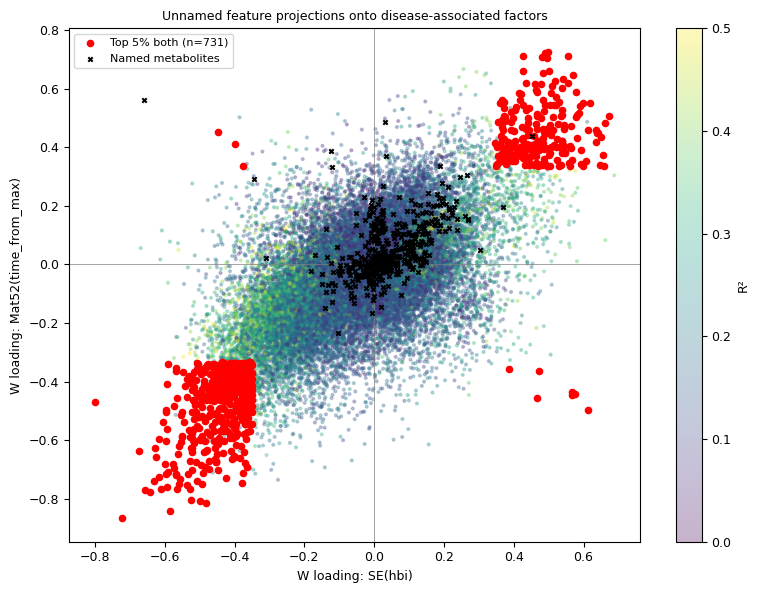


Saved to multioutput/output/unnamed_feature_projections.csv


In [39]:
## Identify Candidate Biomarkers on SE(hbi) and Mat52(time_from_max)

R2_THRESHOLD = 0.2  # minimum variance explained by MOGP factors

# Factor indices for factors of interest
hbi_idx = kernel_labels.index('SE(hbi)')
tfm_idx = kernel_labels.index('Mat52(time_from_max)')

# Build results dataframe
proj_df = unnamed_meta.copy()
proj_df['r2'] = r2
for c, label in enumerate(kernel_labels):
    proj_df[f'W_{c}'] = W_unnamed[:, c]
proj_df['W_hbi'] = W_unnamed[:, hbi_idx]
proj_df['W_tfm'] = W_unnamed[:, tfm_idx]
proj_df['abs_W_hbi'] = np.abs(W_unnamed[:, hbi_idx])
proj_df['abs_W_tfm'] = np.abs(W_unnamed[:, tfm_idx])

# Filter by R²
high_r2 = proj_df[proj_df['r2'] >= R2_THRESHOLD]
print(f"Features with R² >= {R2_THRESHOLD}: {len(high_r2)} ({len(high_r2)/len(proj_df):.1%})")

# Top candidates for SE(hbi)
print(f"\n--- Top 20 unnamed features loading onto SE(hbi) (R² >= {R2_THRESHOLD}) ---")
top_hbi = high_r2.nlargest(20, 'abs_W_hbi')[
    ['Compound','m/z','RT','Method','cv','W_hbi','W_tfm','r2']]
print(top_hbi.to_string(index=False))

# Top candidates for Mat52(time_from_max)
print(f"\n--- Top 20 unnamed features loading onto Mat52(time_from_max) (R² >= {R2_THRESHOLD}) ---")
top_tfm = high_r2.nlargest(20, 'abs_W_tfm')[
    ['Compound','m/z','RT','Method','cv','W_hbi','W_tfm','r2']]
print(top_tfm.to_string(index=False))

# Features loading on BOTH (biologically most interesting)
abs_W = np.abs(W_unnamed)
hbi_pct = np.percentile(abs_W[:, hbi_idx], 95)
tfm_pct = np.percentile(abs_W[:, tfm_idx], 95)
dual_mask = (proj_df['abs_W_hbi'] >= hbi_pct) & (proj_df['abs_W_tfm'] >= tfm_pct) & (proj_df['r2'] >= R2_THRESHOLD)
print(f"\n--- Features in top 5% loading on BOTH SE(hbi) and Mat52(time_from_max) ---")
print(f"  (n={dual_mask.sum()})")
print(proj_df[dual_mask][['Compound','m/z','RT','Method','cv','W_hbi','W_tfm','r2']].to_string(index=False))

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(proj_df['W_hbi'], proj_df['W_tfm'],
                c=proj_df['r2'], cmap='viridis', alpha=0.3, s=4, vmin=0, vmax=0.5)
ax.scatter(proj_df.loc[dual_mask, 'W_hbi'], proj_df.loc[dual_mask, 'W_tfm'],
           c='red', s=20, zorder=5, label=f'Top 5% both (n={dual_mask.sum()})')
# Overlay named metabolites
ax.scatter(W[:, hbi_idx], W[:, tfm_idx],
           c='black', s=10, marker='x', zorder=6, label='Named metabolites')
plt.colorbar(sc, ax=ax, label='R²')
ax.set_xlabel(f'W loading: SE(hbi)')
ax.set_ylabel(f'W loading: Mat52(time_from_max)')
ax.set_title('Unnamed feature projections onto disease-associated factors')
ax.legend(fontsize=8)
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
plt.tight_layout()
plt.savefig('../multioutput/output/unnamed_feature_projection.png', dpi=150, bbox_inches='tight')
plt.show()

# Save projection results
proj_df.to_csv('../multioutput/output/unnamed_feature_projections.csv', index=False)
print("\nSaved to multioutput/output/unnamed_feature_projections.csv")


In [43]:
## m/z Lookup via Local HMDB XML

import xml.etree.ElementTree as ET
import pickle, os, time, bisect
import pandas as pd
import numpy as np

MZ_TOLERANCE_PPM = 5  # tightened from 10 ppm

# LC method -> expected compound class RT ranges for plausibility filter
RT_CLASS_FILTER = {
    'C18-neg':   {'lipids': (6, 99), 'polar': (0, 6)},
    'C18-pos':   {'lipids': (6, 99), 'polar': (0, 6)},
    'C8-pos':    {'lipids': (5, 99), 'polar': (0, 5)},
    'HILIC-pos': {'polar':  (0, 99)},
    'HILIC-neg': {'polar':  (0, 99)},
}

# Accept: feces-annotated, bile-annotated, blood-annotated, or unannotated
# Exclude: compounds annotated ONLY in non-GI biofluids (CSF, amniotic, aqueous humour, etc.)
EXCLUSION_ONLY = {'Cerebrospinal Fluid (CSF)', 'Amniotic Fluid', 'Aqueous Humour',
                  'Ascites Fluid', 'Breath', 'Tears', 'Sweat', 'Lymph', 'Prostate Tissue',
                  'Cellular Cytoplasm', 'Breast Milk'}
GI_BIOSPECIMENS = {'Feces', 'Bile', 'Blood', 'Urine', 'Saliva'}


def mz_to_neutral(mz, method):
    if 'neg' in method.lower():
        return mz + 1.007276
    else:
        return mz - 1.007276


def build_hmdb_mass_index(hmdb_xml_path):
    """
    Build sorted mass index from HMDB XML.
    Each entry: (mass, accession, name, formula, biospecimens_set)
    Only includes entries with monoisotopic mass data.
    """
    NS = 'http://www.hmdb.ca'
    records = []
    current = {}
    in_biospecimen_locations = False
    n = 0
    print('Building HMDB mass index with biospecimen filter...')
    start = time.time()

    for event, elem in ET.iterparse(hmdb_xml_path, events=('start', 'end')):
        tag = elem.tag.replace(f'{{{NS}}}', '')

        if event == 'start' and tag == 'biospecimen_locations':
            in_biospecimen_locations = True
        elif event == 'end' and tag == 'biospecimen_locations':
            in_biospecimen_locations = False

        elif event == 'end' and tag == 'biospecimen' and in_biospecimen_locations:
            if elem.text:
                current.setdefault('biospecimens', set()).add(elem.text.strip())

        elif event == 'end' and tag == 'metabolite':
            if current.get('mass') and current.get('accession'):
                records.append((
                    float(current['mass']),
                    current['accession'],
                    current.get('name', ''),
                    current.get('formula', ''),
                    current.get('biospecimens', set()),
                ))
            current = {}
            in_biospecimen_locations = False
            n += 1
            elem.clear()
            if n % 50000 == 0:
                print(f'  {n} metabolites ({time.time()-start:.0f}s)')

        elif event == 'end' and tag == 'accession' and 'accession' not in current:
            current['accession'] = elem.text or ''
        elif event == 'end' and tag == 'name' and 'name' not in current:
            current['name'] = elem.text or ''
        elif event == 'end' and tag == 'chemical_formula' and 'formula' not in current:
            current['formula'] = elem.text or ''
        elif event == 'end' and tag == 'monisotopic_molecular_weight' and 'mass' not in current:
            if elem.text:
                try: current['mass'] = float(elem.text)
                except: pass

    records.sort(key=lambda x: x[0])
    feces_count = sum(1 for r in records if FECES_BIOSPECIMENS & r[4])
    print(f'Done: {len(records)} entries, {feces_count} detected in feces ({time.time()-start:.0f}s)')
    return records


def lookup_by_mass(neutral_mass, mass_index, ppm_tol=5, feces_only=True):
    tol = neutral_mass * ppm_tol / 1e6
    lo, hi = neutral_mass - tol, neutral_mass + tol
    masses = [r[0] for r in mass_index]
    i = bisect.bisect_left(masses, lo)
    hits = []
    while i < len(mass_index) and mass_index[i][0] <= hi:
        mass, acc, name, formula, biospecimens = mass_index[i]
        if feces_only:
            # Skip if ONLY annotated in non-GI biofluids
            if biospecimens and not (GI_BIOSPECIMENS & biospecimens):
                i += 1
                continue
        ppm_err = abs(mass - neutral_mass) / neutral_mass * 1e6
        hits.append({'hmdb_id': acc, 'name': name, 'formula': formula,
                     'exact_mass': mass, 'ppm_error': round(ppm_err, 2),
                     'biospecimens': ', '.join(sorted(biospecimens))})
        i += 1
    return sorted(hits, key=lambda x: x['ppm_error'])


# Rebuild mass index (delete old one since we need biospecimen data)
mass_index_path = '../multioutput/output/hmdb_mass_index.pkl'
if os.path.exists(mass_index_path):
    # Check if old index has biospecimen data
    with open(mass_index_path, 'rb') as f:
        test = pickle.load(f)
    if len(test[0]) < 5:
        os.remove(mass_index_path)
        print('Removed old index (no biospecimen data)')

if os.path.exists(mass_index_path):
    with open(mass_index_path, 'rb') as f:
        mass_index = pickle.load(f)
    print(f'Loaded mass index: {len(mass_index)} entries')
else:
    mass_index = build_hmdb_mass_index('../examples/iHMP/data/hmdb_metabolites.xml')
    with open(mass_index_path, 'wb') as f:
        pickle.dump(mass_index, f)
    print(f'Saved mass index')

# Get top candidates
R2_MIN = 0.2
hbi_idx_val = kernel_labels.index('SE(hbi)')
tfm_idx_val = kernel_labels.index('Mat52(time_from_max)')
abs_W_u = np.abs(W_unnamed)
hbi_pct95 = np.percentile(abs_W_u[:, hbi_idx_val], 95)
tfm_pct95 = np.percentile(abs_W_u[:, tfm_idx_val], 95)

high_r2 = proj_df[proj_df['r2'] >= R2_MIN].copy()
top_hbi = high_r2.nlargest(20, 'abs_W_hbi')
top_tfm = high_r2.nlargest(20, 'abs_W_tfm')
dual = high_r2[(high_r2['abs_W_hbi'] >= hbi_pct95) & (high_r2['abs_W_tfm'] >= tfm_pct95)]
candidates = pd.concat([top_hbi, top_tfm, dual]).drop_duplicates('Compound').head(40)

print(f'\nQuerying {len(candidates)} candidates (5 ppm, feces-detected only)...')
results = []
for _, row in candidates.iterrows():
    neutral = mz_to_neutral(row['m/z'], row['Method'])
    hits = lookup_by_mass(neutral, mass_index, ppm_tol=MZ_TOLERANCE_PPM, feces_only=True)
    results.append({
        'Compound': row['Compound'],
        'm/z': row['m/z'],
        'RT': row['RT'],
        'Method': row['Method'],
        'neutral_mass': round(neutral, 4),
        'W_hbi': round(row['W_hbi'], 3),
        'W_tfm': round(row['W_tfm'], 3),
        'r2': round(row['r2'], 3),
        'n_hits': len(hits),
        'top_match': hits[0]['name'] if hits else 'No match',
        'top_match_hmdb': hits[0]['hmdb_id'] if hits else '',
        'top_match_formula': hits[0]['formula'] if hits else '',
        'top_match_ppm': hits[0]['ppm_error'] if hits else None,
        'all_matches': '; '.join(h['name'] for h in hits[:3]) if hits else '',
    })

lookup_df = pd.DataFrame(results)
lookup_df.to_csv('../multioutput/output/unnamed_candidate_mz_lookup.csv', index=False)

print(f'Candidates with GI-relevant matches: {(lookup_df["n_hits"] > 0).sum()}/{len(lookup_df)}')
print()
matched = lookup_df[lookup_df['n_hits'] > 0].sort_values('r2', ascending=False)
print(matched[['Compound','m/z','RT','Method','W_hbi','W_tfm','r2',
               'top_match','top_match_formula','top_match_ppm','all_matches']].to_string(index=False))


Loaded mass index: 217879 entries

Querying 40 candidates (5 ppm, feces-detected only)...
Candidates with GI-relevant matches: 12/40

    Compound      m/z    RT    Method  W_hbi  W_tfm    r2                                 top_match top_match_formula  top_match_ppm                                                                                                                      all_matches
 HILn_QI6175 357.2803  3.52 HILIC-neg -0.642 -0.776 0.579        Tetracosapentaenoic acid (24:5n-6)          C24H38O2           1.10                             Tetracosapentaenoic acid (24:5n-6); Tetracosapentaenoic acid (24:5n-3); 1-Phenyl-1,3-octadecanedione
HILn_QI11501 435.3122  3.74 HILIC-neg -0.674 -0.638 0.556                              Varanic acid          C26H44O5           1.38                                                                                                                     Varanic acid
  C8p_QI6646 394.3315  4.82    C8-pos -0.611 -0.767 0.537                    N-L